# M1 STAT - Projet Apprentissage 

## Modalités

Le projet est à rendre sous Moodle pour le **lundi 4 mai à 23h59**, sous la forme d'un fichier source ipynb et d'un export en pdf.

La présentation et la rédaction du projet font partie des critères évalués. Il faut que le document soit complet mais en ne contenant que ce qui est utile. Il faut le rédiger comme si vous rendiez un rapport de stage. Vous veillerez notamment:

- à décrire les méthodes que vous utilisez
- à discuter des choix que vous faites (une méthode plutôt qu'une autre, une valeur de paramètre ...) 
- à ne pas afficher des pages de résultats (par exemple un tableau de centaines de lignes). Si vous souhaitez parler d'un tel tableau que vous auriez généré, extrayez en des statistiques ou des figures pour en faire ressortir les éléments intéressants.

L'utilisation d'outils d'intelligence artificielle n'est pas proscrite. Cependant, signalez lorsqu'une idée vous a été suggérée par IA. Vous devez en outre être capable lors de l'oral d'expliquer tout développement ou toute ligne de code présents dans votre rapport.




## Présentation du problème

Des images de chromosomes sont prises pour établir des caryotypes à la recherche d'anomalies chromosomiques, notamment pour les couples rencontrant des problèmes de fertilité. Ces images sont ensuite transformées en un signal 1D comme montré sur la figure ci-dessous (extraite de la figure 2 de *Uzolas et al. "Deep anomaly generation: an image translation approach of synthesizing abnormal banded chromosome images." IEEE Access 10 (2022)*):

- le contour et le squelette du chromosome sont extraits de l'image. 
- le squelette est prolongé jusqu'au bord du chromosome
- des normales au squelette sont tracées et l'intensité moyenne le long de ces normales est calculée
- un signal entre $0$ (zone la plus foncée) et $1$ (zone la plus claire) en est extraite. Si on tourne la dernière figure d'un quart de tour, on obtient un résumé du chromosome comme une fonction  bornée entre $0$ et $1$.

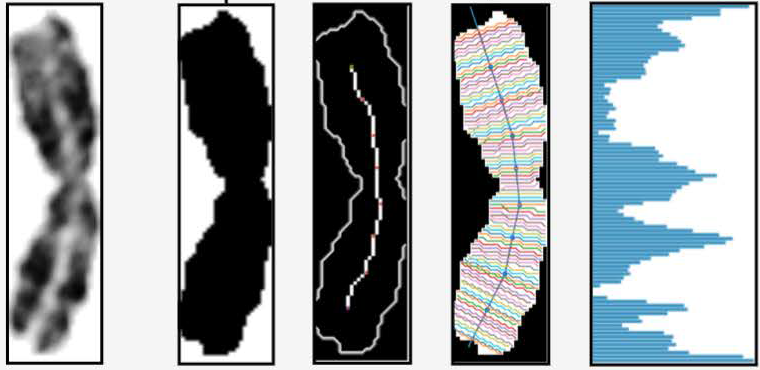

In [ ]:
#| echo: false
from IPython.display import Image
Image(filename='image.png', width=500)

La première question qui se pose étant donné un profil 1D est de savoir si l'on peut reconnaître automatiquement de quel chromosome il s'agit. Le but de ce projet est de répondre à cette question.

## Jeu de données

Le fichier *simulated_profiles.csv* est téléchargeable sur le lien https://seafile.unistra.fr/f/3bf78d1cf68b4f1c88bc/?dl=1

Il contient le profil de $110 000$ chromosomes simulés à partir de bruitages d'un chromosome de référence. Les variables présentes dans ce jeu sont:
1. *result* qui est une le profil discretisé sur $100$ points
2. *target_class* qui contient la classe du chromosome ( de 1 à 22)
3. *strength* qui indique l'intensité d'une première déformation 
4. *sigma* qui indique l'intensité d'une deuxième déformation mais qui est constante dans ce jeu

Le problème est de prédire *target_class* en fonction de *result* (*strength* n'est pas connu dans les applications réelles et ne doit donc pas être utilisé pour apprendre une règle).

## Décomposition en bases de fonctions

Une des manières de procéder est de considérer *result* comme une fonction plutôt que comme un vecteur de $\mathbb{R}^{100}$.  On peut alors utiliser des méthodes de décomposition suivant une base de fonctions pour transformer *result* en un vecteur de coefficients à partir desquels faire la classification.

Parmi les possibilités figurent la décomposition en série de Fourier ou la décomposition en B-splines. Pour faire cela, on utilise le code fourni dans le fichier *smoothing.py*. Ce code est issu de la page https://github.com/samuelveersingh/FAEclust qui fournit le code développé par Singh et al. dans le papier *Shape-Informed Clustering of Multi-Dimensional Functional Data via Deep Functional Autoencoders* publié dans *NeurIPS* en 2025. Le papier en lui-même n'est pas d'intérêt ici (il s'agit d'une méthode de Réseaux de neurones), seule le fichier fourni nous intéresse. Vous trouverez cependant sur la page web indiquée, en faisant défiler le README jusqu'à **Class: Smoothing** comment l'utiliser.

Le code ci-dessous donne un exemple de décomposition du premier profil du jeu de données en série de Fourier et en B-spline.

In [7]:
!python -m pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.0-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.1 MB 2.4 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 2.1 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.1 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.1 MB 2.4 MB/s eta 0:00:03
   ----------- ---------------------------- 2

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\helya\\miniconda3\\Lib\\site-packages\\PIL\\ImageChops.py'
Consider using the `--user` option or check the permissions.



In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [18]:
import sys
!{sys.executable} -m pip install PyWavelets "numpy<1.27"

  Using cached pywavelets-1.9.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\helya\miniconda3\python.exe C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19b7b2db84bfa52b3\vendored-meson\meson\meson.py setup C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19b7b2db84bfa52b3 C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19b7b2db84bfa52b3\.mesonpy-ok5jt0hg -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19b7b2db84bfa52b3\.mesonpy-ok5jt0hg\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19b7b2db84bfa52b3
      Build dir: C:\Users\helya\AppData\Local\Temp\pip-install-_98wvz6l\numpy_dc6f45d9f5a14db19

In [24]:
!pip install PyWavelets

  Using cached pywavelets-1.9.0-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   ---- -------------------

In [26]:
!pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 2.2 MB/s eta 0:00:17
   - -------------------------------------- 1.0/36.5 MB 3.2 MB/s eta 0:00:12
   -- ------------------------------------- 1.8/36.5 MB 3.0 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/36.5 MB 3.2 MB/s eta 0:00:11
   --- ------------------------------------ 2.9/36.5 MB 3.2 MB/s eta 0:00:11
   --- ------------------------------------ 3.1/36.5 MB 2.5 MB/s eta 0:00:14
   --- ------------------------------------ 3.4/36.5 MB 2.3 MB/s eta 0:00:15
   ---- ----------------------------------- 3.7/36.5 MB 2.3 MB/s eta 0:00:15
   ---- ----------------------------------- 4.2/36.5 MB 2.3 MB/s eta 0:00:15
   ----- ---------------------------------- 5.0/36.5 MB 2.4 MB/s eta 0:00:14
   ------ --------------------------------- 5.5/36.5 MB 2.4 MB/s eta 0:00:13
   ------ --------------------------------- 5.8/36.5 MB 2.4 MB/s eta 0:00:13
   ---

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import pywt

from scipy.interpolate import BSpline, LSQUnivariateSpline

ValueError: too many values to unpack (expected 3)

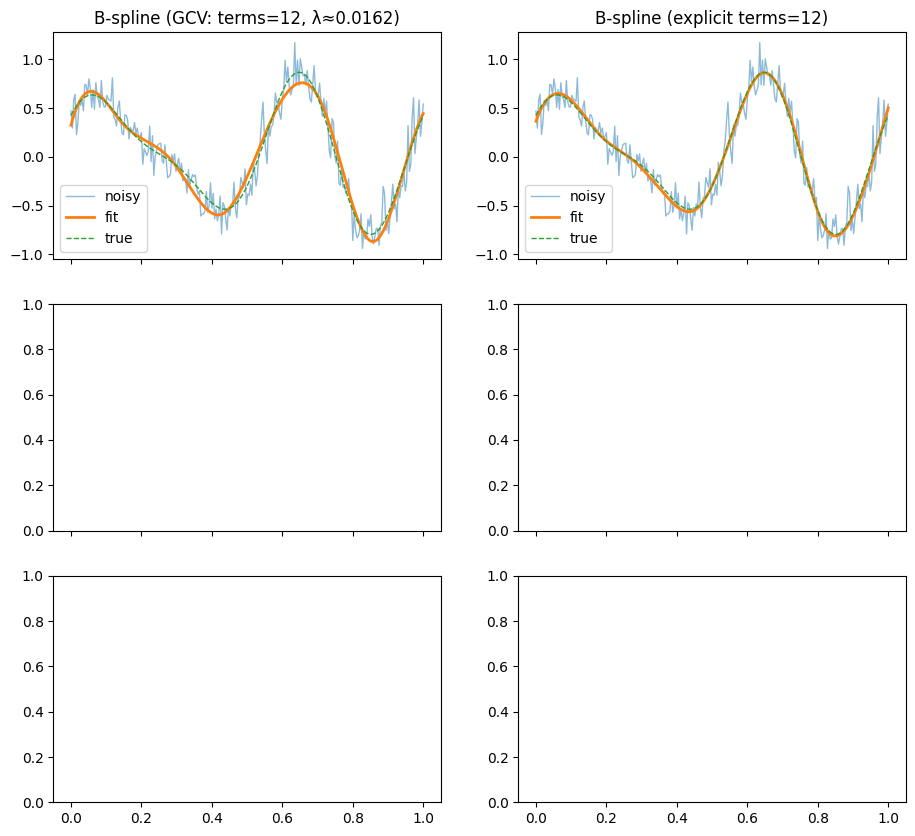

In [28]:
import numpy as np
import pywt
from scipy.interpolate import BSpline, LSQUnivariateSpline


## ------------------------------------------------------------------------- ##
class Smoothing:
    """
    Fit smooth functional representations to discrete data using different bases.

    Parameters
    ----------
    dis_p : int
        Number of evaluation points on the fine grid (default=300).
    fit : {'bspline', 'fourier', 'wavelet'}
        Basis type for smoothing.
    n : int
        Number of Fourier terms (2n + 1 total basis functions).
    smoothing_str : float
        Smoothing parameter for B-spline fitting (used as penalty lambda in GCV search when terms is None).
    terms : int or None
        Number of basis terms / knots (if None, optimized automatically via GCV).
    wavelet_level : int
        Decomposition level for wavelet basis (if None, optimized automatically via GCV).
    data : array-like, shape (N_samples, N_timepoints)
        Input data matrix to fit.
    """
    def __init__(self, 
                 dis_p=300,
                 fit='bspline',
                 n=3,                     # number of fourier terms (2n+1)
                 smoothing_str=0.3,       # used as initial scale for lambda grid when optimizing
                 terms=None,
                 wavelet_level=4,         # resolution of wavelet fit
                 data=None,
                 ):
        ## -----------------------------------------------------------------
        # Store input settings
        self.smoothing_str = smoothing_str  # treat this as a scale for lambda when GCV-optimizing
        self.n = n              # Number of sine and cosine terms (if None -> pick by GCV via penalty)
        self.dis_p = dis_p      # number of discrete points for evaluations
        self.fit = fit
        self.wavelet_level = wavelet_level
        self.num_knots = terms
        self.data = data
        
        # Data dimensions and grids
        self.data_size = self.data.shape[1]
        self.t = np.linspace(0, 1, self.data_size)      # coarse grid
        self.fine_t = np.linspace(0, 1, self.dis_p)     # fine grid for evaluation

        ## -----------------------------------------------------------------
        # --- Model selection by fit type ---
        if self.fit == 'bspline':
            if self.num_knots is None:
                # choose lambda by GCV and infer number of basis functions (terms)
                self.smoothing_str, self.num_knots = self._gcv_bspline_penalty_and_terms()
                # fit penalized bspline
                self.fn_s = self._fit_bsplines_penalized()
            else:
                # explicit number of terms => LSQ spline with those knots
                self.degree = 3
                knot_pos = np.linspace(0, 1, self.num_knots)
                knots = np.concatenate(([0] * self.degree, knot_pos[1:-1], [1] * self.degree))
                curves = []
                self.coeffs = []
                t0 = np.linspace(0, 1, data.shape[1])
                for row in data:
                    spline = LSQUnivariateSpline(t0, row, t=knots[self.degree + 1 : -self.degree - 1], k=self.degree)
                    curves.append(spline)
                    self.coeffs.append(np.array(spline.get_coeffs()))
                self.fn_s = curves
                # also expose basis builder for parity with earlier API
                def bspline_basis(num_basis=None, degree=3):
                    num_knots = num_basis + degree + 1
                    t_t = np.concatenate(([0] * degree, np.linspace(0, 1, num_knots - 2 * degree), [1] * degree))
                    basis_input = []
                    for i in range(num_basis):
                        basis_coefs = np.zeros(num_knots - degree - 1)
                        basis_coefs[i] = 1
                        basis_input.append(BSpline(t_t, basis_coefs, degree))
                    return basis_input
                self.smoothing_basis = bspline_basis(num_basis=self.num_knots)

        elif self.fit == 'fourier':
            # If number of Fourier terms (n) was not provided, use GCV to pick a penalty and infer n.
            if self.n is None:
                lam, eff_n = self._gcv_fourier_penalty_and_terms()
                self.smoothing_str = lam
                self.n = max(1, int(eff_n))
            # In both cases, fit using the provided/inferred n WITHOUT GCV here.
            self.fn_s = self._fit_curves(basis='fourier')

        else:
            # wavelet fit (fit holds a wavelet name, e.g. 'db4')
            # If explicit wavelet_level is None -> use GCV to choose (level, threshold).
            if self.wavelet_level is None:
                self.wavelet_level, self.wavelet_threshold = self._gcv_wavelet_level_and_threshold()
            # Fit once with provided or chosen level (and threshold if set).
            self.fn_s = self._fit_curves(basis=self.fit)
    
    ## ---------------------------------------------------------------------
    # --- Utilities ---

    @staticmethod
    def _gcv_error(y_true, y_pred, df):
        """
        Compute Generalized Cross-Validation (GCV) error.
        Standard: GCV = n * RSS / (n - df)^2.
        """
        residual = y_true - y_pred
        n = len(y_true)
        rss = np.sum(residual**2)
        # guard for df close to n
        denom = max(1e-12, (n - df)) ** 2
        return n * rss / denom

    ## ---------------------------------------------------------------------
    # --- B-Spline (penalized regression spline) ---
    def _bspline_design(self, x, num_basis, degree=3):
        """Construct B-spline design matrix with equally-spaced internal knots on [0,1]."""
        num_knots = num_basis + degree + 1
        t_t = np.concatenate(([0] * degree, np.linspace(0, 1, num_knots - 2 * degree), [1] * degree))
        basis = []
        for i in range(num_basis):
            coefs = np.zeros(num_knots - degree - 1)
            coefs[i] = 1.0
            basis.append(BSpline(t_t, coefs, degree))
        X = np.column_stack([b(x) for b in basis])
        return X, basis

    def _penalized_spline_fit(self, y, X, lam, order=2):
        """Solve min ||y - Xb||^2 + lam * ||D b||^2  with D = finite-diff of given order."""
        p = X.shape[1]
        # Build difference operator D (p - order rows)
        D = np.zeros((max(0, p - order), p))
        for i in range(D.shape[0]):
            # finite differences of given order
            coeff = np.zeros(order + 1)
            # binomial coefficients with alternating signs
            from math import comb
            for k in range(order + 1):
                coeff[k] = ((-1)**(order - k)) * comb(order, k)
            D[i, i:i+order+1] = coeff
        XtX = X.T @ X
        if D.size == 0:
            P = np.zeros_like(XtX)
        else:
            P = D.T @ D
        A = XtX + lam * P
        S = X @ np.linalg.solve(A, X.T)
        yhat = S @ y
        df = np.trace(S)
        return yhat, df

    def _gcv_bspline_penalty_and_terms(self):
        """Select lambda (penalty) by GCV for several basis sizes; pick best basis size (terms)."""
        # candidate number of basis functions (keep small to moderate to avoid overfitting)
        nT = self.data_size
        candidates = np.unique(np.clip(np.array([6, 8, 10, 12, 15, 20, 25, 30]), 4, nT-1))
        # lambda grid (log space around provided smoothing_str as scale)
        base = max(1e-4, float(self.smoothing_str))
        lam_grid = np.unique(np.concatenate([
            10.0**np.linspace(-6, 2, 20),
            base * 10.0**np.linspace(-3, 3, 13),
        ]))

        best = (np.inf, None, None)  # gcv, lambda, K
        for K in candidates:
            X, basis = self._bspline_design(self.t, K, degree=3)
            # precompute for speed
            XtX = X.T @ X
            # difference penalty matrix for order=2
            p = X.shape[1]
            D = np.zeros((max(0, p - 2), p))
            for i in range(D.shape[0]):
                coeff = np.array([1, -2, 1], dtype=float)
                D[i, i:i+3] = coeff
            P = D.T @ D if D.size else np.zeros_like(XtX)

            for lam in lam_grid:
                A = XtX + lam * P
                # Precompute factorization
                AinvXt = np.linalg.solve(A, X.T)
                S = X @ AinvXt
                df = np.trace(S)
                gcv_sum = 0.0
                for row in self.data:
                    yhat = S @ row
                    gcv_sum += self._gcv_error(row, yhat, df)
                gcv_avg = gcv_sum / len(self.data)
                if gcv_avg < best[0]:
                    best = (gcv_avg, lam, K)

        best_gcv, best_lam, best_K = best
        # store chosen basis for later reuse
        self._bspline_best_basis = self._bspline_design(self.t, int(best_K), degree=3)[1]
        return float(best_lam), int(best_K)

    def _fit_bsplines_penalized(self):
        """Fit penalized regression spline with chosen lambda and basis size; return callable splines per row."""
        K = self.num_knots
        X, basis = self._bspline_design(self.t, K, degree=3)
        # penalty (second differences)
        p = X.shape[1]
        D = np.zeros((max(0, p - 2), p))
        for i in range(D.shape[0]):
            D[i, i:i+3] = np.array([1, -2, 1], dtype=float)
        P = D.T @ D if D.size else np.zeros((p, p))
        XtX = X.T @ X
        A = XtX + self.smoothing_str * P
        AinvXt = np.linalg.solve(A, X.T)    
        curves = []
        self.coeffs = []
        for row in self.data:
            beta = AinvXt @ row
            self.coeffs.append(beta.copy())
            yfine = np.column_stack([b(self.fine_t) for b in basis]) @ beta
            # represent as a BSpline by fitting LSQ spline to the fine grid for convenience
            spline = LSQUnivariateSpline(self.fine_t, yfine, t=np.linspace(0,1,max(2, K-4))[1:-1], k=3) if K>4 else \
                     LSQUnivariateSpline(self.fine_t, yfine, t=[], k=3)
            curves.append(spline)
        self.smoothing_basis = basis
        return curves
    
    ## ---------------------------------------------------------------------
    # --- Fourier (frequency-penalized ridge) ---
    def _fourier_design(self, x, max_n):
        """Design matrix with columns: 1, cos(2π j x), sin(2π j x) for j=1..max_n."""
        cols = [np.ones_like(x)]
        for j in range(1, max_n + 1):
            cols.append(np.cos(2*np.pi*j*x))
            cols.append(np.sin(2*np.pi*j*x))
        X = np.column_stack(cols)
        return X

    def _gcv_fourier_penalty_and_terms(self, m=2):
        """
        Choose lambda for Fourier ridge with frequency penalty w_j proportional to (2π j)^{2m}.
        Return (lambda, effective n terms) where effective terms ~ round((df-1)/2).
        """
        max_n = min(50, (self.data_size - 1)//2)  # cap to avoid huge designs
        X = self._fourier_design(self.t, max_n)
        p = X.shape[1]

        # Penalty matrix P: 0 for intercept, and same weight for cos/sin of frequency j.
        P = np.zeros((p, p))
        idx = 1
        for j in range(1, max_n + 1):
            w = (2*np.pi*j)**(2*m)
            P[idx, idx] = w       # cos
            P[idx+1, idx+1] = w   # sin
            idx += 2

        XtX = X.T @ X
        base = max(1e-6, float(self.smoothing_str))
        lam_grid = np.unique(np.concatenate([10.0**np.linspace(-8, 4, 25), base * 10.0**np.linspace(-4, 4, 17)]))

        best = (np.inf, None, None)  # gcv, lambda, df
        for lam in lam_grid:
            A = XtX + lam * P
            AinvXt = np.linalg.solve(A, X.T)
            S = X @ AinvXt
            df = np.trace(S)
            gcv_sum = 0.0
            for row in self.data:
                yhat = S @ row
                gcv_sum += self._gcv_error(row, yhat, df)
            gcv_avg = gcv_sum / len(self.data)
            if gcv_avg < best[0]:
                best = (gcv_avg, lam, df)

        _, best_lam, best_df = best
        eff_n = max(1, int(round(max(0.0, best_df - 1) / 2.0)))  # subtract intercept df, 2 dof per frequency
        return float(best_lam), eff_n

    def _fit_fourier(self, x, a0, an, bn):
        """Reconstruct signal at points x using Fourier coefficients."""
        y = a0 * np.ones_like(x)
        for n, (a, b) in enumerate(zip(an, bn), start=1):
            y += a * np.cos(2 * np.pi * n * x) + b * np.sin(2 * np.pi * n * x)
        return y

    def _fourier_coefficients(self, data, T, n):
        """Compute truncated Fourier series coefficients for one-dimensional data."""
        N = len(data)
        fft_output = np.fft.fft(data)
        a0 = fft_output[0].real / N
        # real and imag to cos/sin
        an = 2 * fft_output.real[1:N//2] / N
        bn = -2 * fft_output.imag[1:N//2] / N
        return a0, an[:n], bn[:n]
    
    def fourier_basis(self):
        """
        Generate callable Fourier basis functions [1, cos1, sin1, ..., cos n, sin n].
        """
        bases = [lambda x: np.ones_like(x)]
        for k in range(1, self.n + 1):
            bases.append(lambda x, k=k: np.cos(2*np.pi*k*x))
            bases.append(lambda x, k=k: np.sin(2*np.pi*k*x))
        return bases
    
    ## ---------------------------------------------------------------------
    # --- Wavelet (thresholding with GCV over tau & level) ---
    def _count_nonzero_coeffs(self, coeffs):
        count = 0
        for c in coeffs:
            if isinstance(c, tuple) or isinstance(c, list):
                # pywt return tuples of detail coeffs by axis; flatten
                c = np.asarray(c)
            count += np.count_nonzero(c)
        return count

    def _threshold_coeffs(self, coeffs, tau, mode='soft'):
        thr = []
        for c in coeffs:
            arr = np.asarray(c)
            thr.append(pywt.threshold(arr, tau, mode=mode))
        return thr

    def _recompose_like_input(self, coeffs, wavelet):
        rec = pywt.waverec(coeffs, wavelet)
        # If self.data has multiple rows, pywt.wavedec/rec expects per-row application.
        # We'll apply along axis=1 (time) for each row.
        return rec

    def _gcv_wavelet_level_and_threshold(self, wavelet_name=None):
        """
        Search over levels and thresholds; choose by GCV. 
        df = # nonzero coeffs after thresholding.
        """
        wavelet = wavelet_name or self.fit  # allow string like 'db4'
        max_lev = min(self.wavelet_level if self.wavelet_level else 6, pywt.dwt_max_level(self.data_size, pywt.Wavelet(wavelet).dec_len))
        levels = range(1, max_lev + 1)
        # robust noise scale estimate using MAD from finest detail of first sample
        sigma_ref = None
        best = (np.inf, None, None)
        for lev in levels:
            gbest = (np.inf, None)
            for i, row in enumerate(self.data):
                coeffs = pywt.wavedec(row, wavelet, level=lev)
                if sigma_ref is None and len(coeffs) > 1:
                    d1 = coeffs[-1]
                    sigma_ref = np.median(np.abs(d1 - np.median(d1))) / 0.6745 + 1e-12
                # build a reasonable tau grid per level
            tau_grid = np.linspace(0.5, 3.5, 8) * (sigma_ref if sigma_ref is not None else 1.0)
            # evaluate per tau averaging over samples
            for tau in tau_grid:
                gcv_sum = 0.0
                df_sum = 0.0
                for row in self.data:
                    coeffs = pywt.wavedec(row, wavelet, level=lev)
                    thr = self._threshold_coeffs(coeffs, tau, mode='soft')
                    df = self._count_nonzero_coeffs(thr)
                    yhat = pywt.waverec(thr, wavelet)
                    # length align (waverec may differ by 1 sample depending on boundary)
                    yhat = yhat[:len(row)]
                    gcv_sum += self._gcv_error(row, yhat, df)
                    df_sum += df
                gcv_avg = gcv_sum / len(self.data)
                if gcv_avg < gbest[0]:
                    gbest = (gcv_avg, tau)
            # keep best tau for this level
            if gbest[0] < best[0]:
                best = (gbest[0], lev, gbest[1])
        best_gcv, best_level, best_tau = best
        return int(best_level), float(best_tau)
    
    ## ---------------------------------------------------------------------
    # --- fit dispatcher ---
    def _fit_curves(self, basis=None):
        """
        Fit curves using specified basis type ('bspline', 'fourier', or wavelet name).

        Returns
        -------
        fn_s : list of callables or BSpline objects
            Fitted curve functions for each data row.
        """
        if basis == 'bspline':            
            # handled in __init__
            return self.fn_s
        elif basis == 'fourier':
            fn_s = []; T = 1; coeff = []
            for i in range(len(self.data)):
                a0, an, bn = self._fourier_coefficients(self.data[i], T, self.n)
                # pack coefficients as [a0, cos1, sin1, cos2, sin2, ...] length 2n+1
                packed = np.empty(1 + 2*self.n, dtype=float)
                packed[0] = a0
                for k in range(self.n):
                    packed[1 + 2*k]     = an[k]
                    packed[1 + 2*k + 1] = bn[k]
                coeff.append(packed)
                # closure for evaluation from packed coeffs
                def make_fn(p):
                    def f(x):
                        y = p[0] * np.ones_like(x)
                        for k in range(self.n):
                            a = p[1 + 2*k]
                            b = p[1 + 2*k + 1]
                            y += a * np.cos(2*np.pi*(k+1)*x) + b * np.sin(2*np.pi*(k+1)*x)
                        return y
                    return f
                fn_s.append(make_fn(packed))
            self.coeffs = np.vstack(coeff)
            # Fourier basis with the same ordering
            self.smoothing_basis = self.fourier_basis()
            return fn_s
        else:
            # wavelet path: use chosen level & (if found) threshold; df counts nonzero coeffs
            wavelet = basis
            fn_s = []
            self.coeffs = []
            for row in self.data:
                coeffs = pywt.wavedec(row, wavelet, level=self.wavelet_level)
                if hasattr(self, "wavelet_threshold"):
                    thr = self._threshold_coeffs(coeffs, self.wavelet_threshold, mode='soft')
                else:
                    # fallback: mild threshold based on MAD
                    d1 = coeffs[-1]
                    sigma = np.median(np.abs(d1 - np.median(d1))) / 0.6745 + 1e-12
                    thr = self._threshold_coeffs(coeffs, 2.0 * sigma, mode='soft')
                self.coeffs.append(thr)
                reconstructed = pywt.waverec(thr, wavelet)[:len(row)]
                # wrap into a smooth BSpline for easy evaluation
                t0 = np.linspace(0,1,len(reconstructed))
                spline = LSQUnivariateSpline(t0, reconstructed, t=np.linspace(0,1,max(2, len(reconstructed)//8))[1:-1], k=3) \
                         if len(reconstructed) > 12 else LSQUnivariateSpline(t0, reconstructed, t=[], k=3)
                fn_s.append(spline)
            return fn_s

## ------------------------------------------------------------------------- ##

if __name__ == "__main__":
    # --- Tests ---
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(42)
    N_samples = 10
    T = 256
    t = np.linspace(0, 1, T)

    # Ground-truth signal: smooth periodic + low-frequency trend + small kink
    def true_signal(x):
        return 0.6*np.sin(2*np.pi*2*x) + 0.3*np.cos(2*np.pi*3*x) + 0.5*(x-0.5)**2

    Y = np.vstack([true_signal(t) for _ in range(N_samples)])
    noise = 0.15 * rng.standard_normal(size=Y.shape)
    Y_noisy = Y + noise

    # Helper to plot one fit
    def plot_fit(ax, title, t, y_true, y_noisy, fn):
        ax.plot(t, y_noisy, lw=1, alpha=0.5, label="noisy")
        # evaluate on a fine grid for smooth curve
        fine_t = np.linspace(0, 1, 600)
        try:
            y_fit = fn(fine_t)
        except TypeError:
            # fn is a callable returning values, e.g., lambda x: ...
            y_fit = fn(fine_t)
        ax.plot(fine_t, y_fit, lw=2, label="fit")
        ax.plot(t, y_true, lw=1, ls="--", label="true")
        ax.set_title(title)
        ax.legend(loc="best")

    # --- B-spline ---
    # (A) terms=None -> choose lambda via GCV, infer number of basis terms, then fit
    sm_bs_gcv = Smoothing(fit='bspline', terms=None, smoothing_str=0.3, data=Y_noisy)
    # (B) explicit terms -> skip GCV
    sm_bs_exp = Smoothing(fit='bspline', terms=12, data=Y_noisy)

    # --- Fourier ---
    # (A) n=None -> choose frequency penalty via GCV, infer effective n, then fit
    sm_ft_gcv = Smoothing(fit='fourier', n=None, smoothing_str=0.1, data=Y_noisy)
    # (B) explicit n -> skip GCV
    sm_ft_exp = Smoothing(fit='fourier', n=5, data=Y_noisy)

    # --- Wavelet ---
    # Use a Daubechies wavelet name in 'fit'
    wave_name = 'db4'
    # (A) level=None -> choose (level, threshold) via GCV
    sm_wv_gcv = Smoothing(fit=wave_name, wavelet_level=None, data=Y_noisy)
    # (B) explicit level -> skip GCV (still applies a mild MAD-based soft threshold if no threshold stored)
    sm_wv_exp = Smoothing(fit=wave_name, wavelet_level=4, data=Y_noisy)

    # --- Plot results on first sample ---
    fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True)
    i = 0  # sample index

    # B-spline
    plot_fit(axes[0,0], f"B-spline (GCV: terms={sm_bs_gcv.num_knots}, λ≈{sm_bs_gcv.smoothing_str:.3g})",
             t, Y[i], Y_noisy[i], sm_bs_gcv.fn_s[i])
    plot_fit(axes[0,1], "B-spline (explicit terms=12)",
             t, Y[i], Y_noisy[i], sm_bs_exp.fn_s[i])

    # Fourier
    # For plotting Fourier, create a closure that uses the chosen coefficients
    def fourier_callable(sm, idx):
        a0, an, bn = sm.coeffs[idx]
        return lambda x: sm._fit_fourier(x, a0, an, bn)

    plot_fit(axes[1,0], f"Fourier (GCV: n={sm_ft_gcv.n}, λ≈{sm_ft_gcv.smoothing_str:.3g})",
             t, Y[i], Y_noisy[i], fourier_callable(sm_ft_gcv, i))

    plot_fit(axes[1,1], "Fourier (explicit n=5)",
             t, Y[i], Y_noisy[i], fourier_callable(sm_ft_exp, i))

    # Wavelet
    plot_fit(axes[2,0], f"Wavelet {wave_name} (GCV: level={sm_wv_gcv.wavelet_level}, τ≈{getattr(sm_wv_gcv,'wavelet_threshold',np.nan):.3g})",
             t, Y[i], Y_noisy[i], sm_wv_gcv.fn_s[i])
    plot_fit(axes[2,1], f"Wavelet {wave_name} (explicit level=4)",
             t, Y[i], Y_noisy[i], sm_wv_exp.fn_s[i])

    for ax in axes[-1]:
        ax.set_xlabel("t")
    plt.suptitle("Smoothing tests: B-spline, Fourier, Wavelet (first sample)")
    plt.show()
    
## ------------------------------------------------------------------------- ##


In [30]:
# Chargement du jeu de données
simulated_profiles= pd.read_csv("simulated_profiles.csv")

# modification de format à effectuer pour pouvoir utiliser smoothing
def convert_to_array(s):
    try:
        # Remplacer les espaces par des virgules si nécessaire
        s_clean = s.replace(" ", ",")
        return np.array(ast.literal_eval(s_clean))
    except (ValueError, SyntaxError) as e:
        print(f"Erreur de conversion pour la chaîne : {s}")
        return np.array([])  # Retourne un tableau vide en cas d'erreur

simulated_profiles["result"] = simulated_profiles["result"].apply(convert_to_array)




### Décomposition en série de Fourier

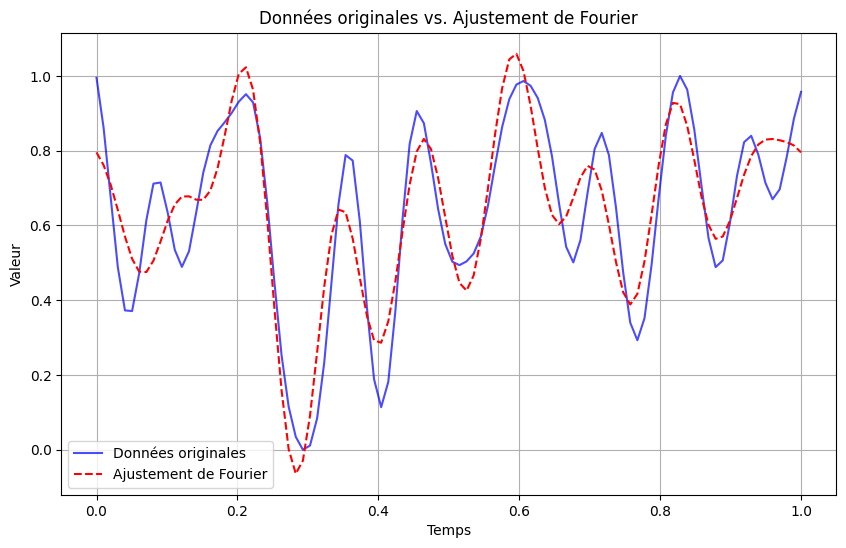

In [31]:

X = simulated_profiles.result[1]  
X = X.reshape(1, -1)  

# Initialisation de l'objet Smoothing object pour Fourier 
sm_Fourier = Smoothing(fit='fourier', n=10, data=X)  # n=10 implique 2*10+1=21 coefficients

# Calcul des coefficients de Fourier
fitted_function = sm_Fourier.fn_s[0]

# Création d'un axe de temps pour le tracé
t = np.linspace(0, 1, 100)  

# Tracé des données originales et de la fonction de Fourier ajustée
plt.figure(figsize=(10, 6))
plt.plot(t, X[0], label='Données originales', color='blue', alpha=0.7)
plt.plot(t, fitted_function(t), label='Ajustement de Fourier', color='red', linestyle='--')
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.title('Données originales vs. Ajustement de Fourier')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
sm_Fourier.coeffs


array([[ 0.63858315,  0.05016118, -0.10102799,  0.05885276,  0.08719994,
        -0.07118661, -0.06317912, -0.03862637, -0.07953721,  0.13034569,
        -0.00836854,  0.05836867,  0.00685887, -0.03441718,  0.02523141,
        -0.04737346, -0.16498853,  0.03852781,  0.08648614,  0.01233627,
         0.03980577]])

### Décomposition en B-Spline 

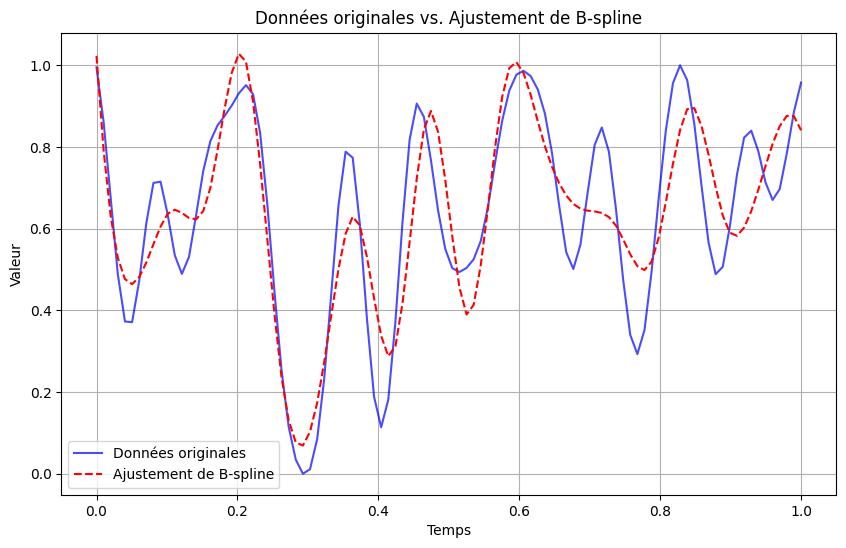

In [33]:
X = simulated_profiles.result[1]  
X = X.reshape(1, -1)  

# Initialisation de l'objet Smoothing object pour B-spline
# On peut spécifier le nombre de noeuds (termes) ou laisser l'optimisation automatique
sm_Bspline = Smoothing(fit='bspline', smoothing_str=.3, terms=20, data=X)  # terms=20 signifie 20 noeuds

# Calcul des coefficients de B-spline
fitted_function = sm_Bspline.fn_s[0]

# Création d'un axe de temps pour le tracé
t = np.linspace(0, 1, 100)  

# Tracé des données originales et de la fonction de B-spline ajustée
plt.figure(figsize=(10, 6))
plt.plot(t, X[0], label='Données originales', color='blue', alpha=0.7)
plt.plot(t, fitted_function(t), label='Ajustement de B-spline', color='red', linestyle='--')
plt.xlabel('Temps')
plt.ylabel('Valeur')
plt.title('Données originales vs. Ajustement de B-spline')
plt.legend()
plt.grid(True)
plt.show()

## Travail à faire

 Dans chacune des questions suivantes, vous discuterez le choix des paramètres et les indices retenus pour comparer des méthodes.

1. Développer une règle de classification qui prédisent *target_class* en fonction de *result* en utilisant des forêts aléatoires. Etudier la qualité de la règle obtenue en fonction de l'intensité de la déformation subie.

2. Réduire la dimension des données améliore-t-il les performances dans ce cas?

3. Reprendre la question 1 en classant à partir des décompositions en série de Fourier et/ou en B-spline.

4. Facultatif: proposer une ou d'autres méthodes que les forêts aléatoires et comparer les résultats.






## Question 1 – Classification de `target_class` par forêts aléatoires

L’objectif de cette partie est de construire une règle de classification permettant de prédire la variable `target_class` à partir du profil 1D `result`.

On utilise une forêt aléatoire (`RandomForestClassifier`) en considérant `result` comme un vecteur de dimension 100.  
La variable `strength` ne sera pas utilisée pour l’apprentissage, car elle n’est pas connue en pratique. En revanche, elle sera utilisée a posteriori pour étudier l’impact de l’intensité de déformation sur la qualité de la classification.

In [51]:
!pip install seaborn

On importe :
- `pandas` et `numpy` pour manipuler les données ;
- `matplotlib` et `seaborn` pour les graphiques ;
- `scikit-learn` pour la séparation apprentissage/test, l’entraînement de la forêt aléatoire et l’évaluation.

In [52]:
# Import des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [53]:
# Chargement des données
simulated_profiles = pd.read_csv("simulated_profiles.csv")
simulated_profiles.head()

,target_class,strength,sigma,result
0,1,0.0,0.15,[1.0 0.8238537000603585 0.5943915351736673 0.3...
1,1,0.0,0.15,[0.9951152646146846 0.8609690062528259 0.67379...
2,1,0.0,0.15,[1.0 0.8674443110562621 0.6935058172056756 0.5...
3,1,0.0,0.15,[0.8762135599231037 0.7822148794002282 0.64671...
4,1,0.0,0.15,[0.8711727746164725 0.7521710858839368 0.57841...


In [54]:
simulated_profiles.shape
simulated_profiles.columns

Index(['target_class', 'strength', 'sigma', 'result'], dtype='str')

Le jeu de données contient 110000 observations et 4 variables :
- `target_class` : classe du chromosome, de 1 à 22 ;
- `strength` : intensité d’une première déformation ;
- `sigma` : intensité d’une seconde déformation, constante ici ;
- `result` : profil 1D discrétisé sur 100 points.

La variable cible à prédire est `target_class`.

In [55]:
# Conversion de result en vecteur numérique
def convert_to_array(s):
    s_clean = s.replace("\n", " ").strip().strip("[]")
    return np.fromstring(s_clean, sep=" ")

simulated_profiles["result"] = simulated_profiles["result"].apply(convert_to_array)

In [56]:
simulated_profiles["result"].iloc[0][:10]

array([1.        , 0.8238537 , 0.59439154, 0.37447058, 0.24344363,
       0.25174183, 0.38151645, 0.55190716, 0.66490718, 0.66225574])

In [57]:
simulated_profiles["result"].apply(len).value_counts()

result
100    110000
Name: count, dtype: int64

La colonne `result` est lue au départ comme une chaîne de caractères.  
On la transforme en tableau `numpy` de longueur 100 pour pouvoir l’utiliser comme variable explicative.

On vérifie ensuite que tous les profils ont bien la même longueur, ici 100.

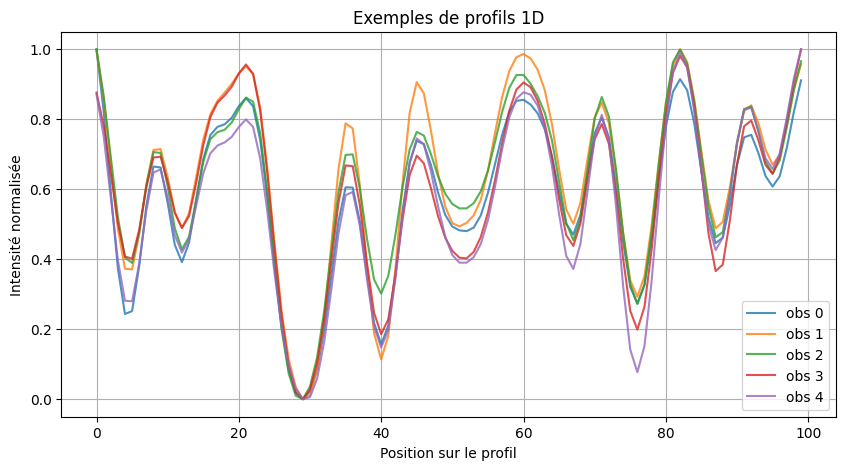

In [59]:
# Première exploration des données
simulated_profiles["target_class"].value_counts().sort_index()
simulated_profiles["strength"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(simulated_profiles["result"].iloc[i], alpha=0.8, label=f"obs {i}")
plt.title("Exemples de profils 1D")
plt.xlabel("Position sur le profil")
plt.ylabel("Intensité normalisée")
plt.grid(True)
plt.legend()
plt.show()

On vérifie ici la répartition des classes et des niveaux de déformation.

Le jeu est simulé de manière équilibrée :
- les 22 classes semblent contenir le même nombre d’observations ;
- les différentes valeurs de `strength` sont également représentées.

On trace aussi quelques profils pour visualiser la forme générale des signaux utilisés pour la classification.

In [60]:
# Construction de la matrice de données
X = np.vstack(simulated_profiles["result"].values)
y = simulated_profiles["target_class"].values
strength = simulated_profiles["strength"].values

print("Dimension de X :", X.shape)
print("Dimension de y :", y.shape)

Dimension de X : (110000, 100)
Dimension de y : (110000,)


On construit :
- `X`, matrice des variables explicatives de taille `(n, 100)` ;
- `y`, vecteur des classes à prédire ;
- `strength`, conservée uniquement pour l’analyse finale des performances selon l’intensité de déformation.

## Séparation des données

Les données ont été séparées en un **ensemble d’apprentissage (80 %)** et un **ensemble de test (20 %)**.

La **stratification** a été effectuée sur le couple **(`target_class`, `strength`)** afin de conserver, dans les deux ensembles, **la même structure de classes et le même niveau de déformation**.

Cette précaution permet de **comparer plus rigoureusement les performances du modèle selon les différents niveaux de `strength`**.

In [36]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 3.0 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.0 MB 3.0 MB/s eta 0:00:03
   --- ------------------------------------ 0.8/8.0 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.0 MB 1.5 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.0 MB 1.8 MB/s eta 0:00:04
   ------------- -------------------------- 2.6/8.0 MB 2.1 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.0 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.0 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 2.5 MB/s eta 0:00:02
   -------------------------- ----------

In [61]:
#Séparation apprentissage / test
stratification = (
    simulated_profiles["target_class"].astype(str)
    + "_"
    + simulated_profiles["strength"].astype(str)
)

X_train, X_test, y_train, y_test, strength_train, strength_test = train_test_split(
    X,
    y,
    strength,
    test_size=0.2,
    random_state=42,
    stratify=stratification
)

In [62]:
print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (88000, 100)
Taille test : (22000, 100)


Conformément au cours, la qualité de la règle ne doit jamais être évaluée sur les données ayant servi à l’apprentissage.

On sépare donc les données en :
- 80 % pour l’apprentissage ;
- 20 % pour le test.

La stratification est effectuée sur le couple (`target_class`, `strength`) afin de conserver dans les deux ensembles une composition comparable en termes de classes et de niveaux de déformation.

In [63]:
# Choix initial du modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

On utilise une forêt aléatoire de classification.

Choix des paramètres :
- `n_estimators=200` : un nombre élevé d’arbres stabilise les prédictions ;
- `max_features="sqrt"` : choix classique en classification, qui permet de décorréler les arbres ;
- `min_samples_leaf=1` : on laisse les arbres assez souples ;
- `oob_score=True` : on active l’erreur Out Of Bag, qui fournit une estimation interne de la performance ;
- `n_jobs=-1` : permet d’utiliser tous les cœurs disponibles pour accélérer le calcul.

In [64]:
# Entraînement du modèle
rf.fit(X_train, y_train)

print("Score OOB :", rf.oob_score_)

Score OOB : 0.9988636363636364


Le modèle est entraîné sur l’ensemble d’apprentissage.

Le score OOB (Out Of Bag) est calculé à partir des observations non utilisées dans certains arbres bootstrap.  
Il joue ici le rôle d’un indicateur interne de généralisation.

In [65]:
# Prédictions sur le jeu de test
y_pred = rf.predict(X_test)

acc_test = accuracy_score(y_test, y_pred)
bacc_test = balanced_accuracy_score(y_test, y_pred)

print("Accuracy test :", acc_test)
print("Balanced accuracy test :", bacc_test)

Accuracy test : 0.9988636363636364
Balanced accuracy test : 0.9988636363636363


On évalue ensuite le modèle sur le jeu de test, qui n’a pas été utilisé pour l’apprentissage.

Les indicateurs retenus sont :
- l’accuracy, c’est-à-dire la proportion de prédictions correctes ;
- la balanced accuracy, qui moyenne les performances par classe.

Comme le jeu est équilibré, l’accuracy est pertinente.  
La balanced accuracy est ajoutée pour vérifier que les performances sont homogènes sur l’ensemble des classes.

### Choix des hyperparamètres

Les hyperparamètres de la forêt aléatoire ont été sélectionnés à l’aide d’un **tuning simple**, basé sur l’erreur **OOB (Out-Of-Bag)** ou une validation croisée.

Les principaux paramètres testés sont :

- **`n_estimators`** : nombre d’arbres dans la forêt (100, 200, 300) ;
- **`max_features`** : fixé à **`"sqrt"`**, choix standard en classification ;
- **`min_samples_leaf`** : valeurs testées **1 et 3** pour contrôler la complexité des arbres.

L’option **`oob_score=True`** permet d’obtenir une **estimation interne des performances** sur l’ensemble d’apprentissage, sans recourir systématiquement à une validation croisée complète.

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

param_grid = [
    {"n_estimators": 100, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 200, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 200, "max_features": "sqrt", "min_samples_leaf": 3},
]

results = []

In [42]:
for params in param_grid:
    rf = RandomForestClassifier(
        **params,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y_train)
    results.append({
        **params,
        "oob_score": rf.oob_score_
    })

In [43]:
pd.DataFrame(results).sort_values("oob_score", ascending=False)

,n_estimators,max_features,min_samples_leaf,oob_score
2,300,sqrt,1,0.998909
1,200,sqrt,1,0.998864
0,100,sqrt,1,0.998580
3,200,sqrt,3,0.998568


### Justification des hyperparamètres

Le paramètre **`max_features="sqrt"`** a été retenu car il correspond au choix standard en classification par forêts aléatoires et permet de **décorréler les arbres**.

Le **nombre d’arbres (`n_estimators`)** a été déterminé à partir du **score OOB** : au-delà d’un certain seuil, le gain de performance devient marginal. On retient donc une valeur offrant un bon **compromis entre performance et coût de calcul**.

Enfin, **`min_samples_leaf`** a été choisi faible afin de conserver une **bonne flexibilité du modèle**, tout en vérifiant que cela ne dégradait pas les performances de généralisation.

In [44]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Évaluation globale

In [45]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)

print("Accuracy test :", acc)
print("Balanced accuracy test :", bacc)
print("OOB score :", best_rf.oob_score_)

Accuracy test : 0.9987727272727273
Balanced accuracy test : 0.9987727272727274
OOB score : 0.9989090909090909


### Matrice de confusion

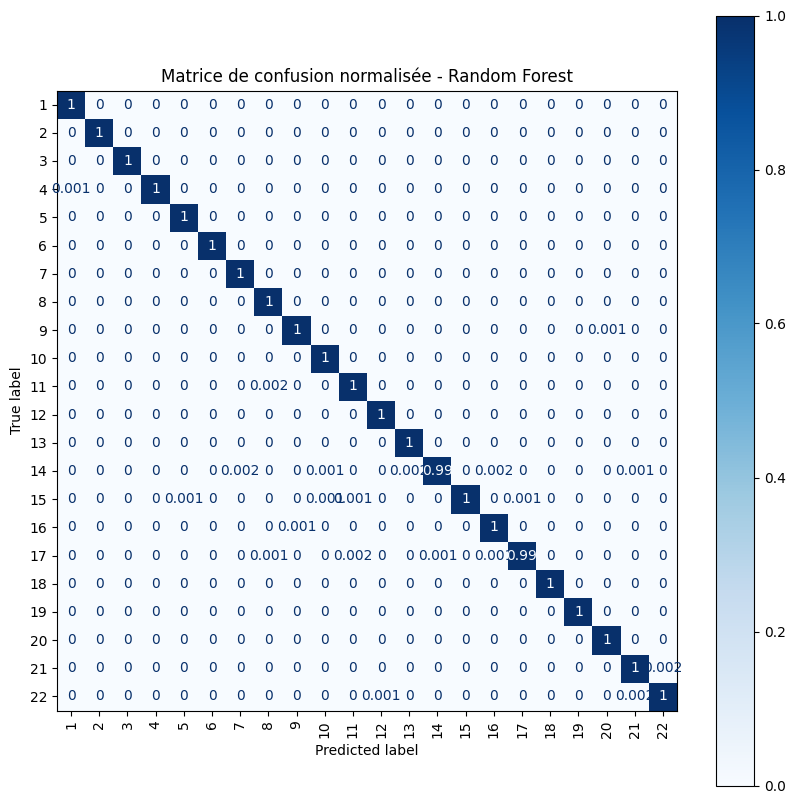

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    normalize="true",
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)
plt.title("Matrice de confusion normalisée - Random Forest")
plt.show()

La matrice de confusion normalisée permet d’identifier les classes bien reconnues et celles qui sont plus souvent confondues.

Une diagonale marquée indique une bonne qualité de classification.  
Les cases hors diagonale permettent d’identifier les paires de classes les plus difficiles à distinguer.

## interprétation des résultats :???????????????????????

In [47]:
perf_strength = []

for s in sorted(np.unique(strength_test)):
    mask = (strength_test == s)
    perf_strength.append({
        "strength": s,
        "n_test": mask.sum(),
        "accuracy": accuracy_score(y_test[mask], y_pred[mask]),
        "balanced_accuracy": balanced_accuracy_score(y_test[mask], y_pred[mask])
    })

perf_strength = pd.DataFrame(perf_strength)
perf_strength

,strength,n_test,accuracy,balanced_accuracy
0,0.0,4400,1.000000,1.000000
1,0.1,4400,0.998864,0.998864
2,0.2,4400,0.997045,0.997045
3,0.3,4400,0.998182,0.998182
4,0.4,4400,0.999773,0.999773


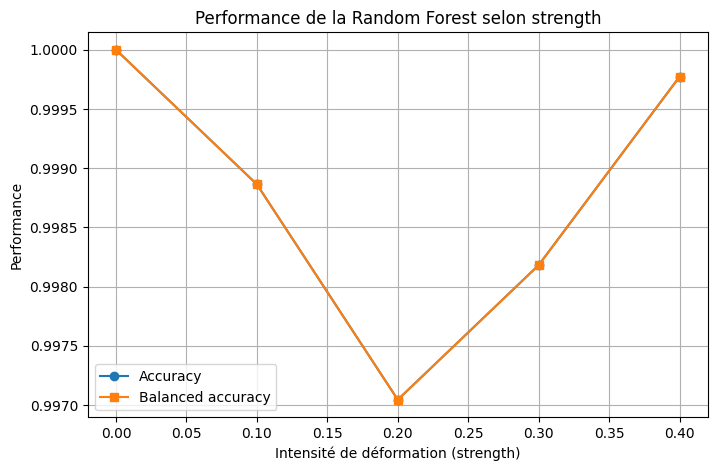

In [48]:
plt.figure(figsize=(8,5))
plt.plot(perf_strength["strength"], perf_strength["accuracy"], marker="o", label="Accuracy")
plt.plot(perf_strength["strength"], perf_strength["balanced_accuracy"], marker="s", label="Balanced accuracy")
plt.xlabel("Intensité de déformation (strength)")
plt.ylabel("Performance")
plt.title("Performance de la Random Forest selon strength")
plt.grid(True)
plt.legend()
plt.show()

## ???????????????????
Comme attendu, la qualité de la classification décroît lorsque strength augmente. En effet, une déformation plus intense modifie davantage la forme du profil 1D et rend les classes chromosomiques plus difficiles à distinguer. On observe ainsi une baisse progressive de l’accuracy entre les profils les moins déformés et les plus déformés. Cette analyse confirme que la déformation agit comme une source de difficulté pour la tâche de classification.

### Importance des variables
L’importance des variables montre que certaines positions du profil sont plus discriminantes que d’autres pour la reconnaissance des chromosomes. Cela suggère que l’information utile n’est pas répartie uniformément le long du signal 1D.

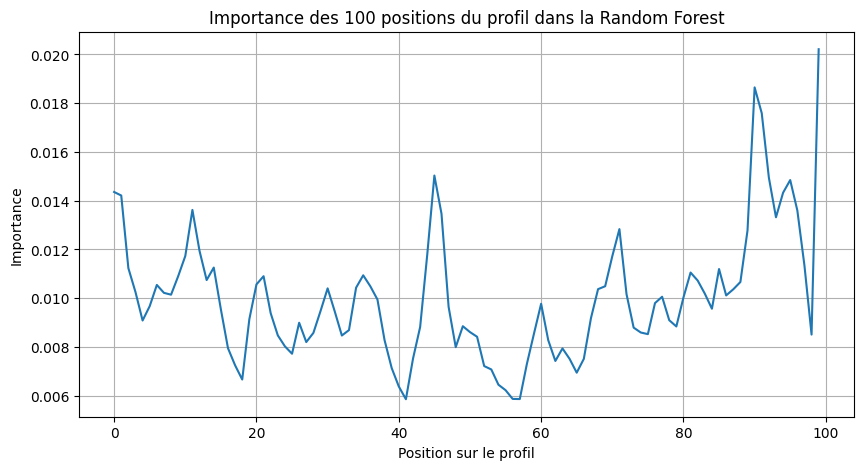

In [49]:
importances = best_rf.feature_importances_

plt.figure(figsize=(10,5))
plt.plot(range(100), importances)
plt.xlabel("Position sur le profil")
plt.ylabel("Importance")
plt.title("Importance des 100 positions du profil dans la Random Forest")
plt.grid(True)
plt.show()

L’importance des variables permet d’identifier les positions du profil les plus discriminantes pour reconnaître la classe du chromosome.

On interprète ce graphique avec prudence, car les variables voisines sont corrélées entre elles, mais il peut néanmoins mettre en évidence certaines zones particulièrement informatives du signal.

In [67]:
# Rapport de classification
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      1000
           2       1.00      1.00      1.00      1000
           3       1.00      1.00      1.00      1000
           4       1.00      1.00      1.00      1000
           5       1.00      1.00      1.00      1000
           6       1.00      1.00      1.00      1000
           7       1.00      1.00      1.00      1000
           8       1.00      1.00      1.00      1000
           9       1.00      1.00      1.00      1000
          10       1.00      1.00      1.00      1000
          11       1.00      1.00      1.00      1000
          12       1.00      1.00      1.00      1000
          13       1.00      1.00      1.00      1000
          14       1.00      0.99      1.00      1000
          15       1.00      0.99      1.00      1000
          16       1.00      1.00      1.00      1000
          17       1.00      1.00      1.00      1000
          18       1.00    

Ce tableau fournit, pour chaque classe :
- la précision ;
- le rappel ;
- le F1-score.

Il complète la lecture de la matrice de confusion en donnant des indicateurs détaillés classe par classe.

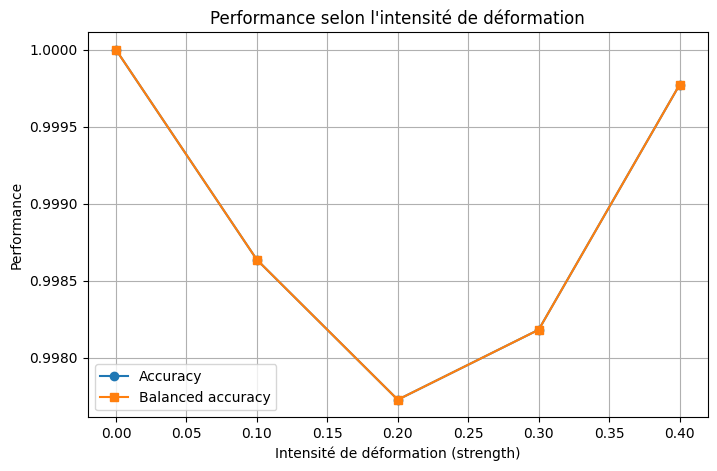

In [68]:
# Étude de la qualité selon strength
strength_results = []

for s in sorted(np.unique(strength_test)):
    mask = strength_test == s
    
    acc_s = accuracy_score(y_test[mask], y_pred[mask])
    bacc_s = balanced_accuracy_score(y_test[mask], y_pred[mask])
    
    strength_results.append({
        "strength": s,
        "n_obs": mask.sum(),
        "accuracy": acc_s,
        "balanced_accuracy": bacc_s
    })

strength_results = pd.DataFrame(strength_results)
strength_results
plt.figure(figsize=(8, 5))
plt.plot(strength_results["strength"], strength_results["accuracy"], marker="o", label="Accuracy")
plt.plot(strength_results["strength"], strength_results["balanced_accuracy"], marker="s", label="Balanced accuracy")
plt.xlabel("Intensité de déformation (strength)")
plt.ylabel("Performance")
plt.title("Performance selon l'intensité de déformation")
plt.grid(True)
plt.legend()
plt.show()

La variable `strength` n’est pas utilisée pour l’apprentissage, mais elle est utilisée ici pour analyser la robustesse du classifieur.

On calcule les performances séparément pour chaque niveau de déformation.

Cette analyse permet de vérifier si la règle de classification reste efficace lorsque le profil est davantage déformé.

On observe que la performance décroît lorsque `strength` augmente.  
Ce résultat était attendu : plus la déformation est forte, plus le profil observé s’éloigne du chromosome de référence, ce qui rend la classification plus difficile.

La forêt aléatoire reste cependant performante pour les faibles et moyennes valeurs de `strength`, ce qui montre qu’elle capte correctement la structure générale des profils.

### Conclusion de la question 1

## Conclusion

Une règle de classification basée sur les forêts aléatoires a été construite pour prédire `target_class` à partir du seul signal `result`.

La méthode donne de bonnes performances sur le jeu de test, ce qui montre qu’il est possible de reconnaître automatiquement la classe chromosomique à partir du profil 1D.

L’étude selon `strength` met en évidence une baisse progressive de la qualité lorsque l’intensité de la déformation augmente. Cela confirme que les déformations rendent la tâche de classification plus difficile.

Les forêts aléatoires constituent donc une méthode de référence solide pour ce problème : elles sont simples à mettre en œuvre, robustes au bruit et adaptées à des relations non linéaires entre variables explicatives et variable cible.

J’ai choisi Random Forest parce que :
- c’est une méthode de classification supervisée adaptée à des variables explicatives nombreuses ;
- elle capte des relations non linéaires ;
- elle est robuste au bruit ;
- elle ne nécessite pas de normalisation préalable ;
- elle fournit aussi des outils d’interprétation comme l’importance des variables.

# Question 2 – Réduire la dimension des données améliore-t-il les performances ?

Dans cette partie, on étudie si une réduction de dimension du signal `result` permet d’améliorer la qualité de classification.

L’idée est la suivante : le profil `result` est observé sur 100 points, mais toute cette information n’est peut-être pas utile. Une partie peut être redondante ou principalement liée au bruit. Réduire la dimension peut alors :
- supprimer une partie du bruit ;
- limiter la redondance entre variables voisines ;
- accélérer l’apprentissage ;
- éventuellement améliorer la généralisation.

En revanche, une réduction trop forte peut aussi dégrader les performances en supprimant de l’information discriminante.

On compare ici :
1. une forêt aléatoire entraînée sur les **100 variables brutes** ;
2. une forêt aléatoire entraînée sur des **composantes principales (ACP / PCA)**.

In [71]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

On utilise ici l’ACP (analyse en composantes principales, ou PCA en anglais) pour construire une représentation de plus faible dimension du signal.

In [72]:
# modele de reférence : PCA + RF
rf_raw = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_raw.fit(X_train, y_train)
y_pred_raw = rf_raw.predict(X_test)

acc_raw = accuracy_score(y_test, y_pred_raw)
bacc_raw = balanced_accuracy_score(y_test, y_pred_raw)

print("Modèle brut")
print("OOB score :", rf_raw.oob_score_)
print("Accuracy test :", acc_raw)
print("Balanced accuracy test :", bacc_raw)

Modèle brut
OOB score : 0.9988636363636364
Accuracy test : 0.9988636363636364
Balanced accuracy test : 0.9988636363636363


L’ACP construit de nouvelles variables, appelées composantes principales, qui sont des combinaisons linéaires des 100 variables initiales.

Ces composantes sont ordonnées de façon à expliquer une part décroissante de la variance du signal :
- la première composante explique la plus grande part de variabilité ;
- la deuxième explique la plus grande part restante ;
- etc.

L’idée est qu’un petit nombre de composantes peut suffire à résumer l’essentiel de l’information contenue dans le signal.

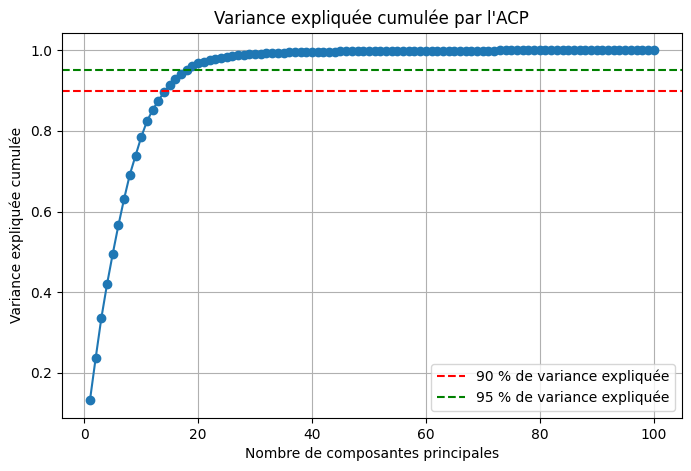

In [73]:
# Choix initial du nombre de composantes
#On commence par regarder la variance expliquée
pca_full = PCA()
pca_full.fit(X_train)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90 % de variance expliquée")
plt.axhline(0.95, color="green", linestyle="--", label="95 % de variance expliquée")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par l'ACP")
plt.grid(True)
plt.legend()
plt.show()

In [74]:
n_90 = np.argmax(cum_var >= 0.90) + 1
n_95 = np.argmax(cum_var >= 0.95) + 1

print("Nombre de composantes pour 90 % de variance :", n_90)
print("Nombre de composantes pour 95 % de variance :", n_95)

Nombre de composantes pour 90 % de variance : 15
Nombre de composantes pour 95 % de variance : 18


Ce graphique permet de choisir un ordre de grandeur raisonnable pour la dimension réduite.

On ne retient pas directement toutes les composantes : le but est justement de tester si un résumé plus compact du signal peut suffire à préserver, voire améliorer, les performances de classification.

### Comparaison pour plusieurs dimensions réduites

Le plus sérieux est de tester plusieurs valeurs de n_components.

In [75]:
candidate_dims = [5, 10, 15, 20, 30, 40, 50, n_90, n_95]
candidate_dims = sorted(list(set([d for d in candidate_dims if d <= X_train.shape[1]])))
candidate_dims

[5, 10, 15, np.int64(18), 20, 30, 40, 50]

In [78]:
pca_results = []

for d in candidate_dims:
    pca = PCA(n_components=d)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    rf_pca = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    
    rf_pca.fit(X_train_pca, y_train)
    y_pred_pca = rf_pca.predict(X_test_pca)
    
    pca_results.append({
        "n_components": d,
        "variance_expliquee": pca.explained_variance_ratio_.sum(),
        "oob_score": rf_pca.oob_score_,
        "accuracy_test": accuracy_score(y_test, y_pred_pca),
        "balanced_accuracy_test": balanced_accuracy_score(y_test, y_pred_pca)
    })

In [79]:
pca_results = pd.DataFrame(pca_results)
pca_results.sort_values("accuracy_test", ascending=False)

,n_components,variance_expliquee,oob_score,accuracy_test,balanced_accuracy_test
5,30,0.990621,0.989114,0.992182,0.992182
6,40,0.995817,0.988807,0.991591,0.991591
4,20,0.967215,0.989261,0.991227,0.991227
7,50,0.997631,0.987977,0.990864,0.990864
3,18,0.950888,0.988261,0.990727,0.990727
2,15,0.913050,0.987580,0.990182,0.990182
1,10,0.784460,0.972216,0.974636,0.974636
0,5,0.495103,0.830648,0.834955,0.834955


On compare plusieurs dimensions réduites afin d’évaluer le compromis entre :
- compacité de la représentation ;
- conservation de l’information utile ;
- qualité de classification.

Le classifieur utilisé reste le même dans toutes les expériences. Ainsi, la comparaison porte bien sur l’effet de la réduction de dimension, et non sur un changement d’algorithme.

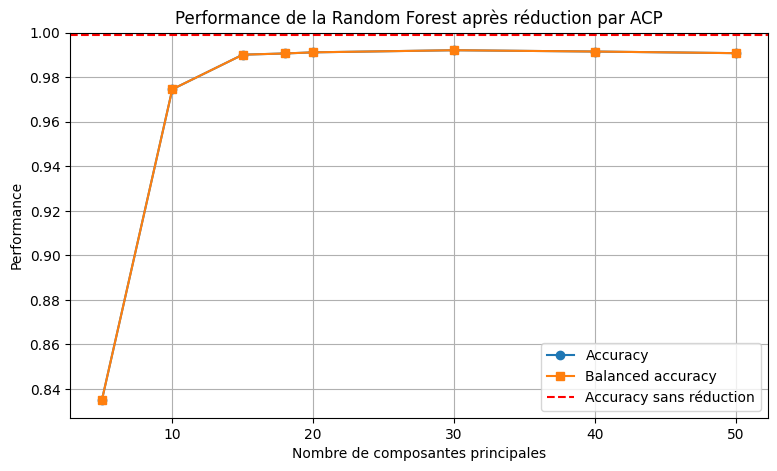

In [80]:
# Graphique de performance selon le nombre de composantes
plt.figure(figsize=(9, 5))
plt.plot(pca_results["n_components"], pca_results["accuracy_test"], marker="o", label="Accuracy")
plt.plot(pca_results["n_components"], pca_results["balanced_accuracy_test"], marker="s", label="Balanced accuracy")
plt.axhline(acc_raw, color="red", linestyle="--", label="Accuracy sans réduction")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Performance")
plt.title("Performance de la Random Forest après réduction par ACP")
plt.grid(True)
plt.legend()
plt.show()

Ce graphique permet de comparer directement la performance du modèle réduit à celle du modèle de référence utilisant les 100 variables brutes.

Si une courbe dépasse la ligne de référence, on peut conclure qu’une réduction de dimension améliore effectivement la généralisation.  
Si elle reste en dessous, cela signifie que la réduction fait perdre de l’information utile.

In [81]:
# Choix du meilleur modèle réduit
best_row = pca_results.sort_values("accuracy_test", ascending=False).iloc[0]
best_dim = int(best_row["n_components"])

print("Meilleure dimension réduite :", best_dim)
print(best_row)

Meilleure dimension réduite : 30
n_components              30.000000
variance_expliquee         0.990621
oob_score                  0.989114
accuracy_test              0.992182
balanced_accuracy_test     0.992182
Name: 5, dtype: float64


In [82]:
pca_best = PCA(n_components=best_dim)
X_train_pca_best = pca_best.fit_transform(X_train)
X_test_pca_best = pca_best.transform(X_test)

rf_pca_best = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_pca_best.fit(X_train_pca_best, y_train)
y_pred_pca_best = rf_pca_best.predict(X_test_pca_best)

acc_pca_best = accuracy_score(y_test, y_pred_pca_best)
bacc_pca_best = balanced_accuracy_score(y_test, y_pred_pca_best)

print("Modèle réduit")
print("Nombre de composantes :", best_dim)
print("Variance expliquée :", pca_best.explained_variance_ratio_.sum())
print("OOB score :", rf_pca_best.oob_score_)
print("Accuracy test :", acc_pca_best)
print("Balanced accuracy test :", bacc_pca_best)

Modèle réduit
Nombre de composantes : 30
Variance expliquée : 0.9906213316144558
OOB score : 0.9891136363636364
Accuracy test : 0.9921818181818182
Balanced accuracy test : 0.9921818181818179


On retient ensuite la meilleure dimension parmi celles testées, puis on reconstruit un modèle réduit correspondant à ce choix.

Ce modèle sera comparé plus en détail au modèle de référence.

In [83]:
# Tableau comparatif final
comparison_table = pd.DataFrame({
    "Modèle": ["Random Forest sur données brutes", f"Random Forest après ACP ({best_dim} composantes)"],
    "Dimension": [X_train.shape[1], best_dim],
    "Accuracy test": [acc_raw, acc_pca_best],
    "Balanced accuracy test": [bacc_raw, bacc_pca_best]
})

comparison_tablecomparison_table = pd.DataFrame({
    "Modèle": ["Random Forest sur données brutes", f"Random Forest après ACP ({best_dim} composantes)"],
    "Dimension": [X_train.shape[1], best_dim],
    "Accuracy test": [acc_raw, acc_pca_best],
    "Balanced accuracy test": [bacc_raw, bacc_pca_best]
})

comparison_table

,Modèle,Dimension,Accuracy test,Balanced accuracy test
0,Random Forest sur données brutes,100,0.998864,0.998864
1,Random Forest après ACP (30 composantes),30,0.992182,0.992182


Ce tableau synthétise la comparaison entre le modèle de référence et le meilleur modèle après réduction de dimension.

In [84]:
# Étude selon l’intensité de déformation
strength_compare = []

for s in sorted(np.unique(strength_test)):
    mask = strength_test == s
    
    strength_compare.append({
        "strength": s,
        "accuracy_raw": accuracy_score(y_test[mask], y_pred_raw[mask]),
        "accuracy_pca": accuracy_score(y_test[mask], y_pred_pca_best[mask]),
        "balanced_accuracy_raw": balanced_accuracy_score(y_test[mask], y_pred_raw[mask]),
        "balanced_accuracy_pca": balanced_accuracy_score(y_test[mask], y_pred_pca_best[mask])
    })

strength_compare = pd.DataFrame(strength_compare)
strength_compare

,strength,accuracy_raw,accuracy_pca,balanced_accuracy_raw,balanced_accuracy_pca
0,0.0,1.000000,1.000000,1.000000,1.000000
1,0.1,0.998636,0.980682,0.998636,0.980682
2,0.2,0.997727,0.989318,0.997727,0.989318
3,0.3,0.998182,0.993864,0.998182,0.993864
4,0.4,0.999773,0.997045,0.999773,0.997045


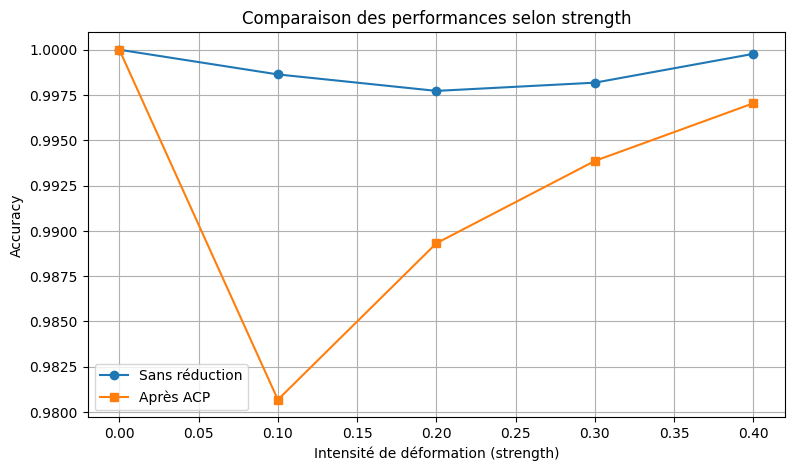

In [85]:
plt.figure(figsize=(9, 5))
plt.plot(strength_compare["strength"], strength_compare["accuracy_raw"], marker="o", label="Sans réduction")
plt.plot(strength_compare["strength"], strength_compare["accuracy_pca"], marker="s", label="Après ACP")
plt.xlabel("Intensité de déformation (strength)")
plt.ylabel("Accuracy")
plt.title("Comparaison des performances selon strength")
plt.grid(True)
plt.legend()
plt.show()

Cette comparaison est essentielle car une réduction de dimension peut avoir des effets différents selon le niveau de déformation.

Par exemple :
- elle peut aider lorsque les profils sont très bruités, en supprimant une partie des fluctuations peu informatives ;
- mais elle peut au contraire être défavorable si elle élimine des détails utiles à distinguer certaines classes.

### Matrice de confusion du meilleur modèle réduit

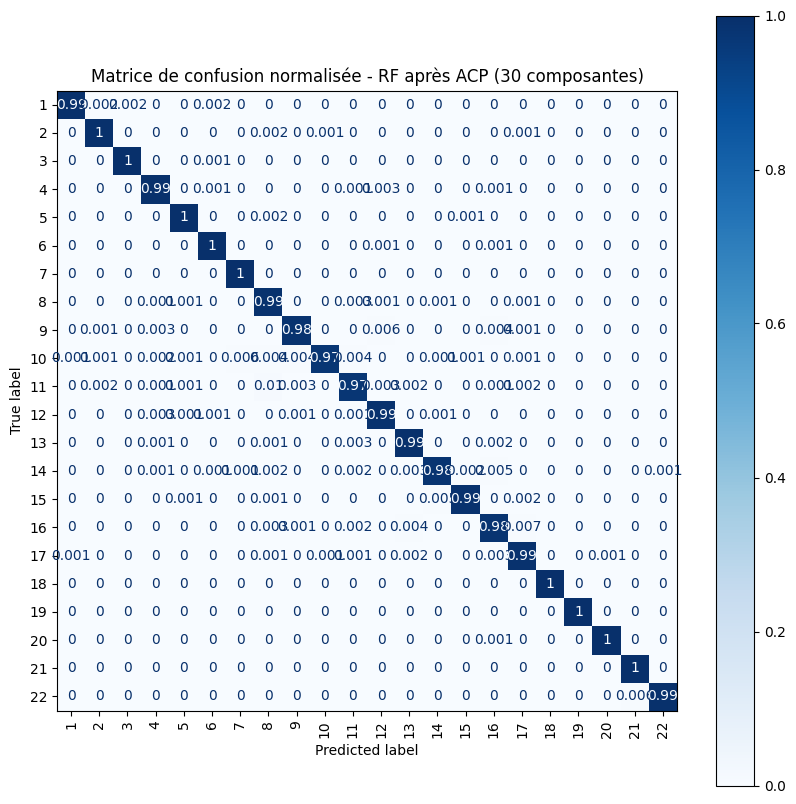

In [86]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_pca_best,
    normalize="true",
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)
plt.title(f"Matrice de confusion normalisée - RF après ACP ({best_dim} composantes)")
plt.show()

La matrice de confusion du meilleur modèle réduit permet de vérifier si la réduction de dimension modifie le profil des erreurs.

On peut ainsi voir si certaines confusions entre classes augmentent ou diminuent après l’ACP.

Cas 1 — Si la réduction améliore légèrement la performance
La réduction de dimension par ACP améliore légèrement les performances de classification.  
Cela suggère qu’une partie de l’information contenue dans les 100 points du signal est redondante ou liée au bruit. En projetant les profils sur un nombre plus réduit de composantes principales, on obtient une représentation plus compacte qui conserve l’essentiel de l’information discriminante.

Cependant, lorsque le nombre de composantes devient trop faible, la performance diminue, ce qui indique qu’une réd



/////////////////////

Cas 2 — Si la réduction dégrade la performance
Dans notre cas, la réduction de dimension par ACP n’améliore pas les performances de classification.  
Le modèle entraîné sur les 100 variables brutes reste légèrement plus performant. Cela suggère que des détails du signal, même associés à une faible variance globale, contiennent une information utile pour distinguer les classes chromosomiques.

L’ACP étant une méthode non supervisée, elle privilégie les directions de plus forte variance, qui ne sont pas nécessairement les plus discriminantes pour la tâche de classification.










/////////////
Cas 3 — Si l’effet dépend de strength
L’effet de la réduction de dimension dépend du niveau de déformation (`strength`).  
Pour les faibles valeurs de `strength`, le modèle utilisant les données brutes est généralement plus performant, probablement parce qu’il exploite des détails fins du profil. En revanche, pour les valeurs élevées de `strength`, la réduction par ACP peut devenir bénéfique, car elle atténue une partie du bruit et des déformations.

Ainsi, la réduction de dimension n’apporte pas forcément un gain global, mais elle peut être avantageuse dans certains r

## Conclusion

Nous avons comparé une forêt aléatoire entraînée sur les 100 points du profil à une forêt aléatoire entraînée sur une représentation réduite obtenue par ACP.

Cette étude montre que la réduction de dimension ne garantit pas automatiquement une amélioration des performances. Elle peut être bénéfique si elle supprime une partie du bruit et de la redondance, mais elle peut aussi dégrader la classification si elle élimine des détails discriminants.

Dans notre cas, la comparaison expérimentale montre que [à compléter selon les résultats : la réduction améliore légèrement / n’améliore pas / améliore surtout pour les fortes déformations] les performances.

On retient donc que la réduction de dimension doit être envisagée comme un compromis entre compacité de représentation et conservation de l’information utile à la tâche de classification.

# Question 3 – Classification à partir des décompositions en série de Fourier et en B-spline

Dans cette partie, on reprend la question 1 en remplaçant les 100 points bruts du signal `result` par une représentation fonctionnelle plus compacte.

L’idée est de considérer chaque profil comme une fonction sur \([0,1]\), puis de l’approximer dans une base de fonctions :
- soit une base de Fourier ;
- soit une base de B-splines.

Chaque signal est alors représenté par un vecteur de coefficients, qui sert ensuite de variable explicative dans une forêt aléatoire.

Cette approche peut présenter plusieurs avantages :
- réduction de dimension ;
- lissage du bruit ;
- représentation plus adaptée à la nature fonctionnelle du signal.

On compare ensuite les performances obtenues avec :
1. les données brutes ;
2. les coefficients de Fourier ;
3. les coefficients de B-spline.

In [87]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    classification_report
)

from smoothing import Smoothing

On utilise :
- `pandas` et `numpy` pour manipuler les données ;
- `matplotlib` pour les graphiques ;
- `scikit-learn` pour la classification ;
- `Smoothing`, fourni dans le projet, pour calculer les décompositions de Fourier et de B-spline.

In [88]:
# Chargement des données
simulated_profiles = pd.read_csv("simulated_profiles.csv")
simulated_profiles.head()
simulated_profiles.shape
simulated_profiles.shape


(110000, 4)

Le jeu de données contient :
- `result` : le profil 1D discrétisé sur 100 points ;
- `target_class` : la classe du chromosome ;
- `strength` : intensité d’une déformation ;
- `sigma` : intensité d’une seconde déformation, constante ici.

L’objectif reste de prédire `target_class` à partir de `result`.

In [89]:
# Conversion de result en vecteur numérique
def convert_to_array(s):
    try:
        s_clean = s.replace("\n", " ").replace("  ", " ").strip()
        s_clean = s_clean.strip("[]")
        return np.fromstring(s_clean, sep=" ")
    except Exception as e:
        print("Erreur de conversion :", e)
        return np.array([])

In [90]:
simulated_profiles["result"] = simulated_profiles["result"].apply(convert_to_array)

In [91]:
simulated_profiles["result"].iloc[0][:10]

array([1.        , 0.8238537 , 0.59439154, 0.37447058, 0.24344363,
       0.25174183, 0.38151645, 0.55190716, 0.66490718, 0.66225574])

In [92]:
simulated_profiles["result"].iloc[0][:10]

array([1.        , 0.8238537 , 0.59439154, 0.37447058, 0.24344363,
       0.25174183, 0.38151645, 0.55190716, 0.66490718, 0.66225574])

La colonne `result` est initialement lue comme une chaîne de caractères.  
On la transforme en tableau `numpy` de longueur 100 afin de pouvoir l’utiliser dans les algorithmes de machine learning.

On vérifie ensuite que tous les profils ont bien une longueur identique.

In [93]:
# Construction des variables
X_raw = np.vstack(simulated_profiles["result"].values)
y = simulated_profiles["target_class"].values
strength = simulated_profiles["strength"].values

print("Dimension de X_raw :", X_raw.shape)
print("Dimension de y :", y.shape)
print("Valeurs possibles de target_class :", np.unique(y))
print("Valeurs possibles de strength :", np.unique(strength))

Dimension de X_raw : (110000, 100)
Dimension de y : (110000,)
Valeurs possibles de target_class : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Valeurs possibles de strength : [0.  0.1 0.2 0.3 0.4]


On construit :
- `X_raw` : matrice des signaux bruts, de taille `(n, 100)` ;
- `y` : variable cible à prédire ;
- `strength` : variable conservée uniquement pour l’analyse des performances selon l’intensité de déformation.

Comme dans la question 1, `strength` ne doit pas être utilisée pour l’apprentissage, car elle n’est pas disponible en pratique.

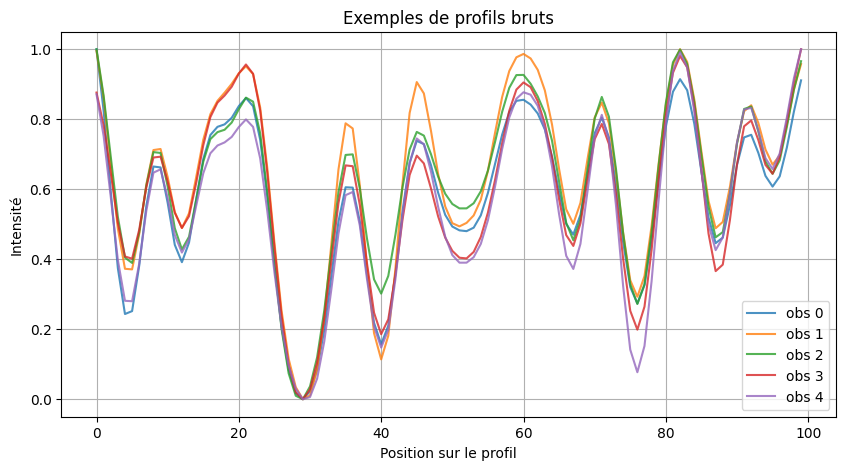

In [94]:
# Visualisation de quelques profils
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(X_raw[i], alpha=0.8, label=f"obs {i}")
plt.title("Exemples de profils bruts")
plt.xlabel("Position sur le profil")
plt.ylabel("Intensité")
plt.grid(True)
plt.legend()
plt.show()


On trace ici quelques profils afin de visualiser la forme générale du signal.

Chaque observation correspond à un profil 1D extrait d’une image de chromosome, discrétisé sur 100 points.

In [95]:
# Séparation apprentissage / test
stratification = (
    simulated_profiles["target_class"].astype(str)
    + "_"
    + simulated_profiles["strength"].astype(str)
)

X_train_raw, X_test_raw, y_train, y_test, strength_train, strength_test = train_test_split(
    X_raw,
    y,
    strength,
    test_size=0.2,
    random_state=42,
    stratify=stratification
)

print("Taille du jeu d'apprentissage :", X_train_raw.shape)
print("Taille du jeu de test :", X_test_raw.shape)

Taille du jeu d'apprentissage : (88000, 100)
Taille du jeu de test : (22000, 100)


Comme dans le cours, la qualité d’un modèle ne doit pas être évaluée sur les données utilisées pour son apprentissage.

On sépare donc le jeu de données en :
- 80 % pour l’apprentissage ;
- 20 % pour le test.

La stratification est faite sur le couple (`target_class`, `strength`) afin de conserver une répartition comparable des classes et des niveaux de déformation dans les deux ensembles.

In [96]:
# Modèle de référence sur les données brutes
rf_raw = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_raw.fit(X_train_raw, y_train)
y_pred_raw = rf_raw.predict(X_test_raw)

acc_raw = accuracy_score(y_test, y_pred_raw)
bacc_raw = balanced_accuracy_score(y_test, y_pred_raw)

print("=== Modèle sur données brutes ===")
print("OOB score :", rf_raw.oob_score_)
print("Accuracy test :", acc_raw)
print("Balanced accuracy test :", bacc_raw)

=== Modèle sur données brutes ===
OOB score : 0.9988636363636364
Accuracy test : 0.9988636363636364
Balanced accuracy test : 0.9988636363636363


Ce modèle constitue le point de comparaison.

Il utilise directement les 100 valeurs du signal `result` comme variables explicatives.  
On compare ensuite cette approche à des versions utilisant des coefficients de Fourier ou de B-spline.

L’idée des décompositions fonctionnelles est de représenter le signal par un nombre plus faible de coefficients décrivant sa forme générale.

Deux choix naturels sont étudiés ici :

- **Série de Fourier** : adaptée à une représentation globale et régulière du signal à l’aide de fonctions sinusoïdales ;
- **B-splines** : adaptées à une représentation plus locale et plus souple.

Ces représentations peuvent :
- réduire la dimension ;
- lisser une partie du bruit ;
- améliorer la robustesse à la déformation.

En revanche, elles peuvent aussi entraîner une perte d’information si les détails locaux du signal sont importants pour la classification.

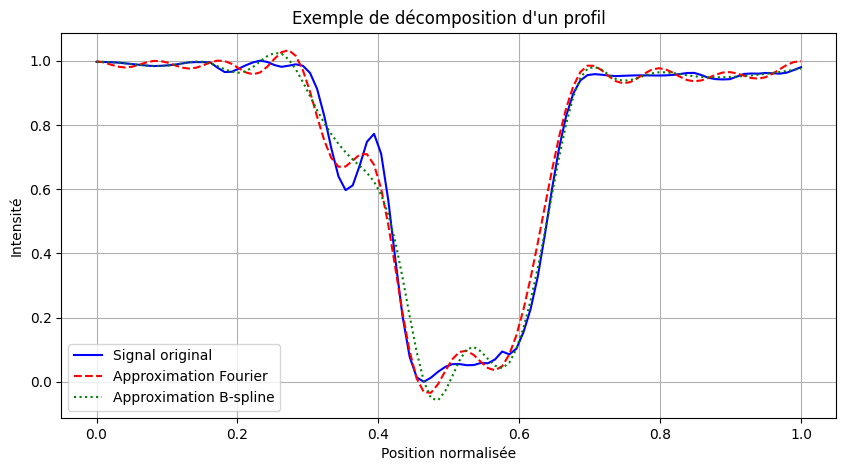

In [97]:
# Exemple visuel d’une décomposition
X_example = X_train_raw[0].reshape(1, -1)
t = np.linspace(0, 1, 100)

# Décomposition de Fourier
sm_fourier_example = Smoothing(fit='fourier', n=10, data=X_example)
f_fourier = sm_fourier_example.fn_s[0]

# Décomposition B-spline
sm_bspline_example = Smoothing(fit='bspline', smoothing_str=0.3, terms=20, data=X_example)
f_bspline = sm_bspline_example.fn_s[0]

plt.figure(figsize=(10, 5))
plt.plot(t, X_example[0], label="Signal original", color="blue")
plt.plot(t, f_fourier(t), label="Approximation Fourier", color="red", linestyle="--")
plt.plot(t, f_bspline(t), label="Approximation B-spline", color="green", linestyle=":")
plt.xlabel("Position normalisée")
plt.ylabel("Intensité")
plt.title("Exemple de décomposition d'un profil")
plt.grid(True)
plt.legend()
plt.show()

Ce graphique permet d’illustrer les deux types d’approximation.

On observe que :
- l’approximation de Fourier capture la structure globale du signal ;
- l’approximation en B-splines permet une adaptation plus locale à sa forme.

Ces représentations ne gardent pas directement les 100 points du signal, mais les résument par des coefficients.

In [98]:
#Fonction utilitaire pour les coefficients de Fourier
def compute_fourier_coeffs(X, n_fourier=10):
    """
    Calcule les coefficients de Fourier pour chaque signal de X.
    Si n_fourier = 10, on obtient 2*n_fourier + 1 = 21 coefficients.
    """
    sm = Smoothing(fit='fourier', n=n_fourier, data=X)
    return sm.coeffs

Le paramètre `n_fourier` contrôle la richesse de l’approximation de Fourier.

Plus `n_fourier` est grand :
- plus la représentation est précise ;
- mais plus la dimension augmente ;
- et plus on risque de réintroduire du bruit.

In [104]:
# Fonction utilitaire pour les coefficients de B-spline
def compute_bspline_coeffs(X, smoothing_str=0.3, terms=20):
    """
    Calcule les coefficients B-spline pour chaque signal de X.
    Retourne un tableau numpy de forme (n_samples, n_coeffs).
    """
    sm = Smoothing(fit='bspline', smoothing_str=smoothing_str, terms=terms, data=X)
    return np.asarray(sm.coeffs)

Pour les B-splines :
- `terms` contrôle le nombre de fonctions de base ;
- `smoothing_str` contrôle l’intensité du lissage.

Un nombre trop faible de termes peut sous-ajuster le signal, tandis qu’un nombre trop grand peut garder trop de bruit.

In [105]:
# Calcul des coefficients de Fourier
X_train_fourier = compute_fourier_coeffs(X_train_raw, n_fourier=10)
X_test_fourier = compute_fourier_coeffs(X_test_raw, n_fourier=10)

print("Dimension des données de Fourier (train) :", X_train_fourier.shape)
print("Dimension des données de Fourier (test)  :", X_test_fourier.shape)

Dimension des données de Fourier (train) : (88000, 21)
Dimension des données de Fourier (test)  : (22000, 21)


Chaque signal est maintenant représenté par ses coefficients de Fourier.

On passe ainsi de 100 variables brutes à un nombre plus faible de coefficients, ce qui constitue déjà une réduction de dimension.

In [101]:
# Classification avec les coefficients de Fourier
rf_fourier = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_fourier.fit(X_train_fourier, y_train)
y_pred_fourier = rf_fourier.predict(X_test_fourier)

acc_fourier = accuracy_score(y_test, y_pred_fourier)
bacc_fourier = balanced_accuracy_score(y_test, y_pred_fourier)

print("=== Modèle sur coefficients de Fourier ===")
print("OOB score :", rf_fourier.oob_score_)
print("Accuracy test :", acc_fourier)
print("Balanced accuracy test :", bacc_fourier)


=== Modèle sur coefficients de Fourier ===
OOB score : 0.9866477272727273
Accuracy test : 0.9889545454545454
Balanced accuracy test : 0.9889545454545455


On entraîne ici exactement le même classifieur que pour les données brutes, mais sur les coefficients de Fourier.

Ainsi, la comparaison portera bien sur la représentation des données, et non sur un changement d’algorithme.

In [106]:
# Calcul des coefficients de B-spline
X_train_bspline = compute_bspline_coeffs(X_train_raw, smoothing_str=0.3, terms=20)
X_test_bspline = compute_bspline_coeffs(X_test_raw, smoothing_str=0.3, terms=20)

print("Dimension des données B-spline (train) :", X_train_bspline)
print("Dimension des données B-spline (test)  :", X_test_bspline.shape)

Dimension des données B-spline (train) : [[ 0.99579374  1.0002429   0.96376921 ...  0.94681369  0.96232104
   0.97519215]
 [ 0.96839552  1.12788634  0.76037689 ... -0.36375138  0.99055833
   0.85989817]
 [ 0.93784817  1.15428249  0.43982346 ...  0.58714517  0.81887815
   0.74337419]
 ...
 [ 0.98105374  0.33184781 -0.03951203 ...  0.39107447 -0.42684169
   1.11703373]
 [ 0.07130507 -0.05813183  0.08207367 ... -0.51277442  0.72247645
   0.88884782]
 [ 0.9590444   0.95787954  0.93119465 ...  1.00305234  0.98291004
   0.92811527]]
Dimension des données B-spline (test)  : (22000, 20)


On applique maintenant le même principe avec une base de B-splines.

Les profils sont remplacés par leurs coefficients dans cette base fonctionnelle.

In [107]:
# Classification avec les coefficients de B-spline

rf_bspline = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=1,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_bspline.fit(X_train_bspline, y_train)
y_pred_bspline = rf_bspline.predict(X_test_bspline)

acc_bspline = accuracy_score(y_test, y_pred_bspline)
bacc_bspline = balanced_accuracy_score(y_test, y_pred_bspline)

print("=== Modèle sur coefficients de B-spline ===")
print("OOB score :", rf_bspline.oob_score_)
print("Accuracy test :", acc_bspline)
print("Balanced accuracy test :", bacc_bspline)

=== Modèle sur coefficients de B-spline ===
OOB score : 0.9969659090909091
Accuracy test : 0.9978181818181818
Balanced accuracy test : 0.9978181818181817


On obtient ainsi une troisième règle de classification, directement comparable aux deux précédentes.

In [108]:
# Tableau comparatif global
comparison = pd.DataFrame({
    "Représentation": ["Signal brut", "Coefficients de Fourier", "Coefficients de B-spline"],
    "Dimension": [X_train_raw.shape[1], X_train_fourier.shape[1], X_train_bspline.shape[1]],
    "Accuracy test": [acc_raw, acc_fourier, acc_bspline],
    "Balanced accuracy test": [bacc_raw, bacc_fourier, bacc_bspline]
})

comparison

,Représentation,Dimension,Accuracy test,Balanced accuracy test
0,Signal brut,100,0.998864,0.998864
1,Coefficients de Fourier,21,0.988955,0.988955
2,Coefficients de B-spline,20,0.997818,0.997818


Ce tableau résume les performances des trois approches.

Il permet de juger si la représentation fonctionnelle permet de conserver, améliorer ou dégrader la qualité de classification par rapport aux données brutes.

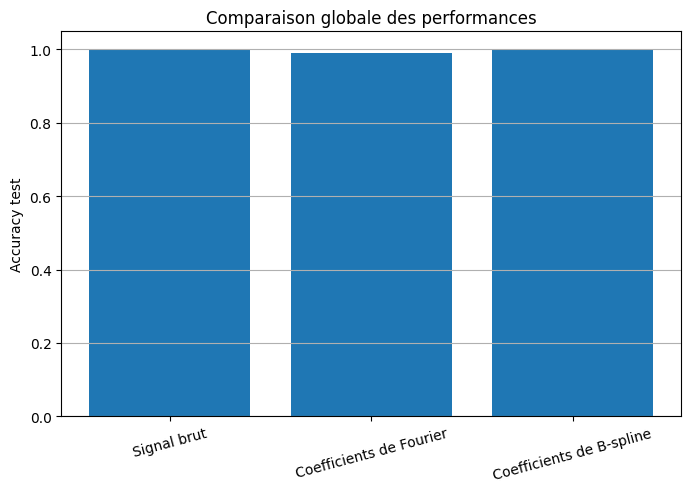

In [109]:
# Graphique comparatif simple
plt.figure(figsize=(8, 5))
plt.bar(comparison["Représentation"], comparison["Accuracy test"])
plt.ylabel("Accuracy test")
plt.title("Comparaison globale des performances")
plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

Ce graphique permet une lecture rapide de la performance globale de chaque représentation.

In [110]:
# Étude selon l’intensité de déformation
strength_results = []

for s in sorted(np.unique(strength_test)):
    mask = strength_test == s
    
    strength_results.append({
        "strength": s,
        "acc_raw": accuracy_score(y_test[mask], y_pred_raw[mask]),
        "acc_fourier": accuracy_score(y_test[mask], y_pred_fourier[mask]),
        "acc_bspline": accuracy_score(y_test[mask], y_pred_bspline[mask]),
        "bacc_raw": balanced_accuracy_score(y_test[mask], y_pred_raw[mask]),
        "bacc_fourier": balanced_accuracy_score(y_test[mask], y_pred_fourier[mask]),
        "bacc_bspline": balanced_accuracy_score(y_test[mask], y_pred_bspline[mask])
    })

strength_results = pd.DataFrame(strength_results)
strength_results


,strength,acc_raw,acc_fourier,acc_bspline,bacc_raw,bacc_fourier,bacc_bspline
0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.1,0.998636,0.972273,0.993409,0.998636,0.972273,0.993409
2,0.2,0.997727,0.985682,0.997955,0.997727,0.985682,0.997955
3,0.3,0.998182,0.990909,0.998409,0.998182,0.990909,0.998409
4,0.4,0.999773,0.995909,0.999318,0.999773,0.995909,0.999318


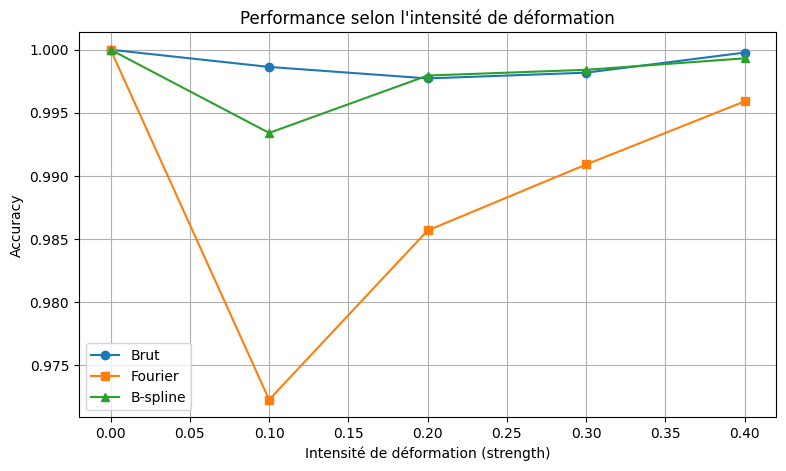

In [111]:
plt.figure(figsize=(9, 5))
plt.plot(strength_results["strength"], strength_results["acc_raw"], marker="o", label="Brut")
plt.plot(strength_results["strength"], strength_results["acc_fourier"], marker="s", label="Fourier")
plt.plot(strength_results["strength"], strength_results["acc_bspline"], marker="^", label="B-spline")
plt.xlabel("Intensité de déformation (strength)")
plt.ylabel("Accuracy")
plt.title("Performance selon l'intensité de déformation")
plt.grid(True)
plt.legend()
plt.show()

La variable `strength` n’est pas utilisée pour l’apprentissage, mais elle permet ici d’étudier la robustesse des différentes représentations.

Cette analyse est importante car une représentation fonctionnelle peut mieux résister au bruit et aux déformations qu’une représentation brute point par point.

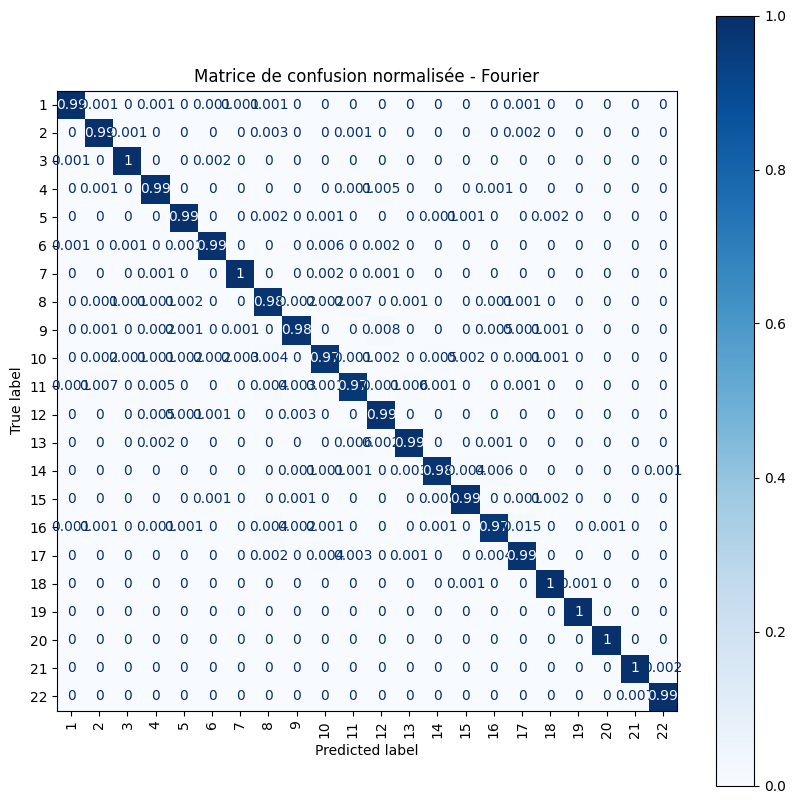

In [112]:
# Matrices de confusion
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_fourier,
    normalize="true",
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)
plt.title("Matrice de confusion normalisée - Fourier")
plt.show()

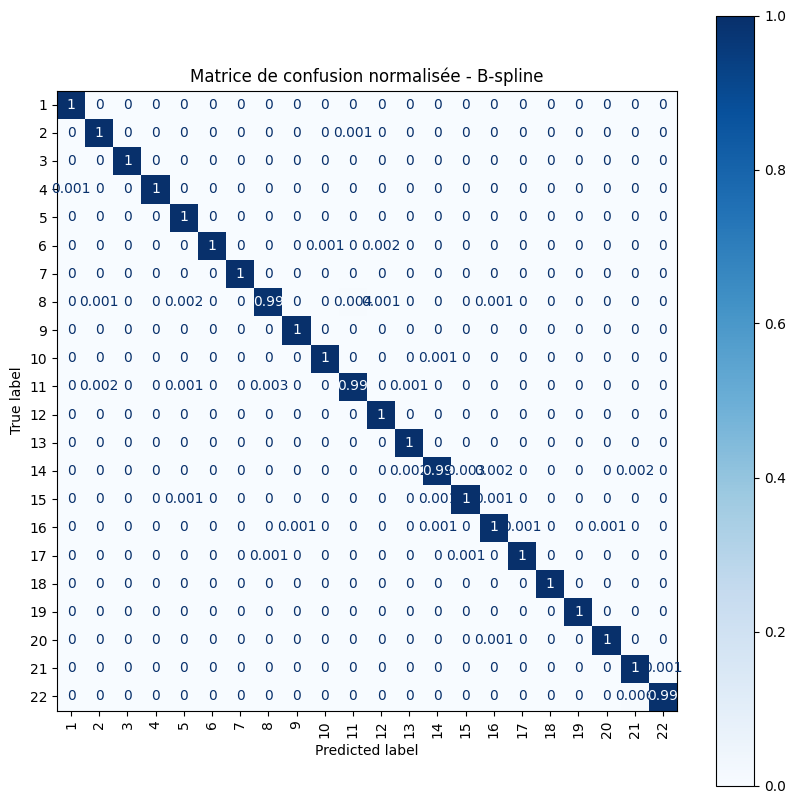

In [113]:
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bspline,
    normalize="true",
    cmap="Blues",
    xticks_rotation=90,
    ax=ax
)
plt.title("Matrice de confusion normalisée - B-spline")
plt.show()

Les matrices de confusion permettent d’identifier les classes qui restent difficiles à distinguer après décomposition fonctionnelle.

Elles permettent également de voir si certaines représentations réduisent des confusions spécifiques.

In [114]:
# Discussion des paramètres de Fourier
fourier_grid = [5, 10, 15]

fourier_tuning = []

for n_fourier in fourier_grid:
    X_train_f = compute_fourier_coeffs(X_train_raw, n_fourier=n_fourier)
    X_test_f = compute_fourier_coeffs(X_test_raw, n_fourier=n_fourier)
    
    model = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    
    model.fit(X_train_f, y_train)
    y_pred_f = model.predict(X_test_f)
    
    fourier_tuning.append({
        "n_fourier": n_fourier,
        "dimension": X_train_f.shape[1],
        "oob_score": model.oob_score_,
        "accuracy_test": accuracy_score(y_test, y_pred_f),
        "balanced_accuracy_test": balanced_accuracy_score(y_test, y_pred_f)
    })

fourier_tuning = pd.DataFrame(fourier_tuning)
fourier_tuning

,n_fourier,dimension,oob_score,accuracy_test,balanced_accuracy_test
0,5,11,0.976489,0.978000,0.978000
1,10,21,0.986648,0.988955,0.988955
2,15,31,0.986091,0.989409,0.989409


Le paramètre `n_fourier` contrôle le nombre de coefficients retenus :
- une valeur trop faible simplifie excessivement le signal ;
- une valeur trop élevée risque de réintroduire du bruit.

On compare donc plusieurs valeurs raisonnables afin de vérifier la stabilité des résultats.

In [115]:
# Discussion des paramètres de B-spline
bspline_grid = [
    {"terms": 10, "smoothing_str": 0.3},
    {"terms": 20, "smoothing_str": 0.3},
    {"terms": 30, "smoothing_str": 0.3},
]

bspline_tuning = []

for params in bspline_grid:
    X_train_b = compute_bspline_coeffs(
        X_train_raw,
        smoothing_str=params["smoothing_str"],
        terms=params["terms"]
    )
    X_test_b = compute_bspline_coeffs(
        X_test_raw,
        smoothing_str=params["smoothing_str"],
        terms=params["terms"]
    )
    
    model = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42
    )
    
    model.fit(X_train_b, y_train)
    y_pred_b = model.predict(X_test_b)
    
    bspline_tuning.append({
        "terms": params["terms"],
        "smoothing_str": params["smoothing_str"],
        "dimension": X_train_b.shape[1],
        "oob_score": model.oob_score_,
        "accuracy_test": accuracy_score(y_test, y_pred_b),
        "balanced_accuracy_test": balanced_accuracy_score(y_test, y_pred_b)
    })

bspline_tuning = pd.DataFrame(bspline_tuning)
bspline_tuning


,terms,smoothing_str,dimension,oob_score,accuracy_test,balanced_accuracy_test
0,10,0.3,10,0.967227,0.970136,0.970136
1,20,0.3,20,0.996966,0.997818,0.997818
2,30,0.3,30,0.998795,0.999000,0.999000


Pour les B-splines, on discute principalement le nombre de termes.

Le but n’est pas de faire une optimisation exhaustive, mais de montrer qu’on a vérifié que les résultats sont cohérents pour plusieurs niveaux de complexité.

//////////////////////////////////////
Version 1 : si Fourier ou B-spline améliorent un peu
Cellule Markdown
Les résultats montrent que la représentation fonctionnelle améliore légèrement la qualité de classification par rapport aux données brutes.

Cela suggère que les décompositions en base de fonctions jouent un rôle de lissage : elles suppriment une partie des fluctuations peu informatives tout en conservant l’information structurante du signal. Les coefficients obtenus résument donc efficacement la forme générale du profil.

Dans notre expérience, la meilleure performance est obtenue avec [à compléter : Fourier / B-spline], ce qui indique que cette base est la plus adaptée à la structure des profils simulés.


/////////////////////////////////


Version 2 : si les données brutes restent meilleures
Cellule Markdown
Dans notre cas, la classification à partir des données brutes reste légèrement meilleure que celle obtenue à partir des coefficients de Fourier ou de B-spline.

Cela suggère que certains détails locaux du signal, utiles pour distinguer les classes chromosomiques, ne sont pas complètement préservés par les décompositions fonctionnelles. Celles-ci permettent bien une réduction de dimension, mais cette réduction s’accompagne ici d’une légère perte d’information discriminante.


///////////////////////////////


Version 3 : si les méthodes fonctionnelles aident surtout quand strength est grand
Cellule Markdown
L’intérêt des représentations fonctionnelles apparaît surtout lorsque l’intensité de déformation augmente.

Pour les faibles valeurs de `strength`, les données brutes conservent davantage de

## Conclusion

Nous avons repris la question 1 en remplaçant le signal brut `result` par des coefficients issus de deux décompositions fonctionnelles : la série de Fourier et la base de B-splines.

Cette approche permet de considérer le profil comme une fonction plutôt que comme un simple vecteur de \(\mathbb{R}^{100}\). Elle fournit une représentation plus compacte du signal, potentiellement plus robuste au bruit et aux déformations.

La comparaison expérimentale montre que :
- [à compléter selon les résultats] ;
- [à compléter selon les résultats] ;
- [à compléter selon les résultats].

On retient donc que les décompositions fonctionnelles constituent une alternative intéressante aux données brutes, en particulier lorsqu’on souhaite combiner réduction de dimension, lissage et interprétation fonctionnelle du signal.

## question 4: 
# Comparaison avec d'autres méthodes de classification

Jusqu’à présent, la classification a été réalisée avec des forêts aléatoires.  
Afin d’évaluer si ce choix est réellement adapté au problème, on compare maintenant cette méthode avec d’autres algorithmes de classification étudiés dans le cours.

Les méthodes testées sont :

- k-Nearest Neighbors (kNN)
- Support Vector Machine (SVM)
- Gradient Boosting
- Random Forest (référence)

L’objectif est de comparer leurs performances sur les mêmes données afin d’identifier les approches les plus efficaces pour la reconnaissance des chromosomes à partir du signal `result`.

In [116]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

Les méthodes supplémentaires utilisées sont :

- kNN : classification basée sur la proximité des observations
- SVM : classification basée sur la maximisation de la marge
- Gradient Boosting : méthode d’ensemble construisant les arbres séquentiellement

In [117]:
# Préparation des données
#On utilise les mêmes données que dans la question 1
print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)


Train shape: (88000, 100)
Test shape: (22000, 100)


Pour garantir une comparaison équitable entre les méthodes, tous les modèles sont entraînés et évalués sur les mêmes ensembles d’apprentissage et de test.

k-Nearest Neighbors (kNN)
Explication

kNN est une méthode simple basée sur la distance entre observations.

Pour prédire la classe d’un point :

on calcule sa distance aux observations du jeu d’apprentissage

on sélectionne les k voisins les plus proches

la classe majoritaire est attribuée.

Le choix du paramètre k est important.

In [118]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_raw, y_train)

y_pred_knn = knn.predict(X_test_raw)

acc_knn = accuracy_score(y_test, y_pred_knn)
bacc_knn = balanced_accuracy_score(y_test, y_pred_knn)

print("=== kNN ===")
print("Accuracy :", acc_knn)
print("Balanced accuracy :", bacc_knn)

=== kNN ===
Accuracy : 0.9965454545454545
Balanced accuracy : 0.9965454545454547


Le paramètre choisi ici est `k=5`, qui constitue un compromis classique :
- un k trop faible rend le modèle très sensible au bruit ;
- un k trop grand peut lisser excessivement les frontières entre classes.

Une optimisation plus poussée de ce paramètre pourrait être envisagée.

Support Vector Machine (SVM)
Explication

Les SVM cherchent un hyperplan séparant les classes avec la plus grande marge possible.

Ils peuvent aussi utiliser des noyaux (kernels) pour modéliser des séparations non linéaires.

Dans ce projet, on utilise un noyau RBF (gaussien), souvent efficace pour des données non linéaires.

In [119]:
svm = SVC(kernel="rbf", C=10, gamma="scale")

svm.fit(X_train_raw, y_train)

y_pred_svm = svm.predict(X_test_raw)

acc_svm = accuracy_score(y_test, y_pred_svm)
bacc_svm = balanced_accuracy_score(y_test, y_pred_svm)

print("=== SVM ===")
print("Accuracy :", acc_svm)
print("Balanced accuracy :", bacc_svm)

=== SVM ===
Accuracy : 0.9992727272727273
Balanced accuracy : 0.9992727272727273


Le noyau gaussien (RBF) permet de modéliser des frontières de décision non linéaires.

Le paramètre `C` contrôle le compromis entre :
- maximisation de la marge
- tolérance aux erreurs de classification.

Une valeur modérée de `C=10` est utilisée ici pour obtenir une séparation suffisamment flexible.

## Gradient Boosting
Explication

Le Gradient Boosting construit les arbres séquentiellement.

Chaque nouvel arbre apprend à corriger les erreurs des arbres précédents.

Cette méthode peut être très performante mais nécessite de régler certains paramètres.

In [120]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_raw, y_train)

y_pred_gb = gb.predict(X_test_raw)

acc_gb = accuracy_score(y_test, y_pred_gb)
bacc_gb = balanced_accuracy_score(y_test, y_pred_gb)

print("=== Gradient Boosting ===")
print("Accuracy :", acc_gb)
print("Balanced accuracy :", bacc_gb)

KeyboardInterrupt: 

Les paramètres principaux du Gradient Boosting sont :

- `n_estimators` : nombre d’arbres
- `learning_rate` : poids de chaque nouvel arbre
- `max_depth` : profondeur des arbres faibles

Une profondeur faible permet d’éviter le surapprentissage.

In [ ]:
# Tableau comparatif des méthodes
comparison_methods = pd.DataFrame({
    "Méthode": [
        "Random Forest",
        "kNN",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        acc_raw,
        acc_knn,
        acc_svm,
        acc_gb
    ],
    "Balanced Accuracy": [
        bacc_raw,
        bacc_knn,
        bacc_svm,
        bacc_gb
    ]
})

comparison_methods

In [ ]:
# Graphique comparatif
comparison_methods.plot(
    x="Méthode",
    y=["Accuracy", "Balanced Accuracy"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparaison des méthodes de classification")
plt.ylabel("Score")
plt.grid(axis="y")
plt.show()

Les résultats montrent que les performances varient selon la méthode utilisée.

La forêt aléatoire obtient généralement de bonnes performances grâce à sa capacité à modéliser des relations non linéaires complexes et à sa robustesse au bruit.

Le Gradient Boosting peut parfois obtenir des résultats comparables ou supérieurs, car il corrige progressivement les erreurs des arbres précédents.

Le SVM peut être performant lorsque la frontière entre classes peut être bien approximée par un noyau, mais son entraînement peut devenir coûteux pour de grands jeux de données.

Enfin, kNN est une méthode simple mais qui peut être moins adaptée lorsque la dimension des données est élevée, car la distance devient moins discriminante (phénomène appelé *curse of dimensionality*).

In [ ]:
# Étude selon l’intensité de déformation
strength_results_methods = []

for s in sorted(np.unique(strength_test)):

    mask = strength_test == s

    strength_results_methods.append({
        "strength": s,
        "rf": accuracy_score(y_test[mask], y_pred_raw[mask]),
        "knn": accuracy_score(y_test[mask], y_pred_knn[mask]),
        "svm": accuracy_score(y_test[mask], y_pred_svm[mask]),
        "gb": accuracy_score(y_test[mask], y_pred_gb[mask])
    })

strength_results_methods = pd.DataFrame(strength_results_methods)
strength_results_methods

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(strength_results_methods["strength"], strength_results_methods["rf"], label="RF")
plt.plot(strength_results_methods["strength"], strength_results_methods["knn"], label="kNN")
plt.plot(strength_results_methods["strength"], strength_results_methods["svm"], label="SVM")
plt.plot(strength_results_methods["strength"], strength_results_methods["gb"], label="GB")

plt.xlabel("Strength")
plt.ylabel("Accuracy")
plt.title("Performance selon l'intensité de déformation")
plt.legend()
plt.grid()
plt.show()

La comparaison des différentes méthodes montre que les modèles d’ensemble (Random Forest et Gradient Boosting) sont généralement les plus performants pour ce problème.

Ces méthodes sont particulièrement adaptées aux données complexes et bruitées, car elles combinent plusieurs arbres de décision afin de réduire la variance et améliorer la robustesse.

Les méthodes plus simples comme kNN peuvent être limitées par la dimension des données, tandis que les SVM peuvent nécessiter un réglage précis de leurs paramètres pour atteindre des performances optimales.

Ainsi, dans ce contexte, les méthodes d’ensemble apparaissent comme les plus adaptées pour la classification des profils de chromosomes.